# Introducción a la IA - Proyecto Final
**Objetivo:** El objetivo de este notebook es aplicar técnicas de aprendizaje no supervisado para agrupar los alojamientos de Airbnb de la Ciudad de México según sus características.

**Autor:** Aarón Eduardo Arceo Arjona

---

## Instrucciones de ejecución

El notebook se puede ejecutar en cualquier computadora sin modificar rutas:
* Los datos se descargan automáticamente desde [Google Drive](https://drive.google.com/drive/folders/1jbMTEdOapi-bUggbXFuWcfcSedJzD0Xp?usp=sharing) en la sección **Carga de los dataframes**. Se guardan en la carpeta `datos/`, que se crea en el directorio de trabajo (la carpeta del notebook en Jupyter/VS Code, o `/content` en Colab). La ruta absoluta se imprime al ejecutar la celda.
* La descarga (~800 MB) solo ocurre la primera vez; en ejecuciones posteriores se reutilizan los archivos descargados.
* Se requiere conexión a internet para descargar los datos y para obtener el contorno de la CDMX desde OpenStreetMap (`osmnx`).
* El notebook se desarrolló en Google Colab (~12 GB de RAM). En equipos con menos memoria, la carga de `calendar.csv` / `reviews.csv` y el clúster jerárquico podrían fallar.

### Opción 1: Google Colab (recomendada)
1. Abrir [Google Colab](https://colab.research.google.com/) → **Archivo → Subir notebook** y seleccionar este archivo.
2. Ejecutar **Entorno de ejecución → Ejecutar todas**.

La primera celda de código instala las paqueterías que Colab no trae preinstaladas.

### Opción 2: Ejecución local (Jupyter o VS Code)
1. Instalar **Python 3.12**. Las versiones fijadas de `numpy` y `pandas` no tienen instaladores para Python 3.13 o superior.
2. Abrir una terminal en la carpeta del notebook (junto a `requirements.txt`), crear un entorno virtual e instalar las dependencias:

```bash
# Windows
py -3.12 -m venv .venv
.venv\Scripts\activate

# macOS / Linux
python3.12 -m venv .venv
source .venv/bin/activate

# Ambos
pip install -r requirements.txt
jupyter lab
```

3. Abrir el notebook y ejecutar **Run → Run All Cells**. En VS Code, seleccionar como kernel el intérprete de `.venv`.

### Versiones y paqueterías
Versión de Python: **3.12** (el notebook se ejecutó con Python 3.12.13 en Google Colab).

| Paquetería | Versión | Uso en el proyecto |
|---|---|---|
| pandas | 2.2.2 | Carga y manipulación de datos |
| numpy | 2.0.2 | Cálculo numérico |
| scikit-learn | 1.6.1 | Escalamiento, imputación, PCA, K-Means, GMM, clúster jerárquico, DBSCAN y métricas |
| scipy | 1.16.3 | Dendrogramas y estadística |
| pyod | 3.6.1 | Detección de outliers con KNN |
| yellowbrick | 1.5 | Método del codo (`KElbowVisualizer`) |
| kneed | 0.8.6 | Detección del punto de codo |
| matplotlib | 3.10.0 | Gráficas |
| seaborn | 0.13.2 | Gráficas estadísticas |
| plotly | 6.5.2 | Gráficas interactivas |
| osmnx | 2.1.0 | Contorno geográfico de la CDMX |
| geopandas | 1.1.3 | Dependencia de osmnx para mapas |
| gdown | 6.4.1 | Descarga de los datos desde Google Drive |
| setuptools | sin versión fija | Provee `distutils`, que `yellowbrick` necesita en Python 3.12 |

Instalar paqueterías

In [ ]:
# Paqueterías que no vienen preinstaladas en Google Colab.
# En ejecución local se instalan todas con: pip install -r requirements.txt
# (setuptools provee distutils, que yellowbrick necesita en Python 3.12)
%pip install -q pyod==3.6.1 osmnx==2.1.0 kneed==0.8.6 yellowbrick==1.5 "gdown>=5.2" setuptools

## Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import sys
import os
from datetime import datetime
import ast
from pathlib import Path
import gdown

# Librerías gráficas
import plotly.express as px
import plotly.io as pio
# Renderizador compatible con VS Code, JupyterLab y Google Colab
pio.renderers.default = 'plotly_mimetype+colab'

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib import offsetbox
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
import osmnx as ox


# Preprocesamiento y Modelado
from pyod.models.knn import KNN
from scipy.stats import chisquare
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
import scipy.stats as stats
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import scipy.cluster.hierarchy as sch
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from kneed import KneeLocator

# Agrupamiento
from sklearn.metrics import silhouette_samples
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import calinski_harabasz_score
import random
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, cophenet, dendrogram
from scipy.spatial.distance import pdist

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Configuracion del display
np.set_printoptions(threshold=sys.maxsize)
pd.set_option('display.max_rows', None, 'display.max_columns', None, 'display.width', None, 'display.max_colwidth', None, 'display.precision', 1, 'display.float_format', '{:,.2f}'.format)

# Rutas del proyecto: se construyen como rutas absolutas en tiempo de ejecución a partir
# del directorio de trabajo (carpeta del notebook en Jupyter/VS Code o /content en Colab)
DIR_DATOS = Path.cwd().resolve() / 'datos'
ox.settings.cache_folder = DIR_DATOS / 'cache_osmnx'

# Paleta de Colores
color1 = '#282832'
color2 = '#77181e'
color3 = '#a92727'
color4 = '#c6d6d6'
color5 = '#dee7e7'

custom_palette_aux = [color2, color1, color4]

print("Bibliotecas importadas correctamente.")

Bibliotecas importadas correctamente.


## Clases y Objetos Auxiliares

In [3]:
def resumen(df, n_rows = 2):
    imprimir = f"""Total de filas: {df.shape[0]} \nTotal de columnas: {df.shape[1]} \nTotal de elementos: {df.size}"""
    print(imprimir)
    return df.head(n_rows)


def is_na_df(df):
    na_summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "columna", 0: "n_missing"})
    )

    na_summary["total"] = len(df)
    na_summary["prop_missing"] = na_summary["n_missing"] / na_summary["total"]
    na_summary["prop_original"] = 1 - na_summary["prop_missing"]

    na_summary = na_summary[na_summary["n_missing"] > 0].reset_index(drop=True)

    total_missing = df.isna().sum().sum()
    total_elements = df.size
    prop_missing_global = total_missing / total_elements
    prop_original_global = 1 - prop_missing_global

    rows_missing = df.isna().any(axis = 1).sum()
    total_rows = df.shape[0]
    prop_missing_rows = rows_missing / total_rows
    prop_original_rows = 1 - prop_missing_rows


    resumen = pd.DataFrame({
        "columna": ["ROWS WITH MISSINGS", "TOTAL", ],
        "n_missing": [rows_missing, total_missing],
        "total": [total_rows, total_elements],
        "prop_missing": [prop_missing_rows, prop_missing_global],
        "prop_original": [prop_original_rows, prop_original_global]
    })

    na_summary = pd.concat([na_summary, resumen], ignore_index=True)

    return na_summary

def score_silueta(
    X,
    min_compo,
    max_compo,
    model_type="kmeans",   # "kmeans" o "gmm"
    random_state=42
):
    silueta = []

    for k in range(min_compo, max_compo):

        if model_type == "kmeans":
            model = KMeans(n_clusters=k, random_state=random_state, n_init = 'auto')
            labels = model.fit_predict(X)

        elif model_type == "gmm":
            model = GaussianMixture(
                n_components=k,
                covariance_type="full",
                random_state=random_state
            )
            labels = model.fit_predict(X)

        else:
            raise ValueError("model_type debe ser 'kmeans' o 'gmm'")

        score = silhouette_score(X, labels, metric="euclidean")
        silueta.append(score)

    df_silueta = pd.DataFrame({
        "N_Clusters": range(min_compo, max_compo),
        "score": silueta
    })

    fig = px.line(
        df_silueta,
        x="N_Clusters",
        y="score",
        markers=True,
        title=f"Número óptimo de clusters - Silueta ({model_type.upper()})"
    )

    fig.show()

def score_silueta_jerarquico(X, min_compo, max_compo):
    silueta = []
    rango_clusters = range(min_compo, max_compo)
    
    for k in rango_clusters:
        modelo = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
        labels = modelo.fit_predict(X)
        
        score = silhouette_score(X, labels, metric="euclidean")
        silueta.append(score)
        print(f"k={k} completado: Silhouette Score = {score:.4f}")
        
    df_silueta = pd.DataFrame({
        "N_Clusters": list(rango_clusters),
        "score": silueta
    })

    fig = px.line(
        df_silueta,
        x="N_Clusters",
        y="score",
        markers=True,
        title="Validación de Clusters - Silueta (Clustering Jerárquico)"
    )

    return fig.show()

def codo_dbscan_automatico(X, min_samples):
    print(f"Calculando distancias para {min_samples} vecinos...")
    
    vecinos = NearestNeighbors(n_neighbors=min_samples)
    vecinos_fit = vecinos.fit(X)
    distancias, indices = vecinos_fit.kneighbors(X)
    distancias_k = np.sort(distancias[:, -1])
    
    df_distancias = pd.DataFrame({
        "Puntos_Ordenados": range(len(distancias_k)),
        "Distancia_eps": distancias_k
    })
    
    fig = px.line(
        df_distancias, x="Puntos_Ordenados", y="Distancia_eps",
        title=f"Curva K-Distance (min_samples={min_samples})",
        labels={"Puntos_Ordenados": "Alojamientos", "Distancia_eps": "Distancia (Epsilon)"}
    )

    return fig.show()


def codo(X,min_compo,max_compo):
    model = KMeans(n_init = 'auto')
    visualizer = KElbowVisualizer(model, k=(min_compo,max_compo)).fit(X)
    return visualizer.show()

def codo_gmm_aic_bic(X, min_compo, max_compo, random_state=42):
    aic_scores = []
    bic_scores = []
    rango_clusters = range(min_compo, max_compo)

    for k in rango_clusters:
        model = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=random_state
        )

        model.fit(X)
        
        aic_scores.append(model.aic(X))
        bic_scores.append(model.bic(X))

    df_metrics = pd.DataFrame({
        "N_Clusters": list(rango_clusters),
        "AIC": aic_scores,
        "BIC": bic_scores
    })

    df_melt = df_metrics.melt(
        id_vars="N_Clusters", 
        value_vars=["AIC", "BIC"],
        var_name="Métrica", 
        value_name="Score"
    )

    fig = px.line(
        df_melt,
        x="N_Clusters",
        y="Score",
        color="Métrica",
        markers=True,
        title="Número óptimo de clusters GMM - Criterios de Información (AIC / BIC)",
        labels={"Score": "Valor del Criterio", "N_Clusters": "Número de Clusters (k)"}
    )

    return fig.show()

def score_calinski(X,min_compo,max_compo):
    calinski = []
    for k in list(range(min_compo, max_compo)):
        km = KMeans(n_clusters=k)
        labels = km.fit_predict(X)
        score = calinski_harabasz_score(X,labels)
        calinski.append(score)
    df_calinski=pd.DataFrame()
    df_calinski["N_Clusters"]=range(min_compo,max_compo)
    df_calinski["score"]=calinski
    fig = px.line(df_calinski, x="N_Clusters", y="score", title="Número de clusters óptimo - Calinski")
    return fig.show()

## 📄 1. Calidad de Datos

### Carga de los dataframes

In [ ]:
# Descarga de los datos desde Google Drive (solo si no se han descargado antes)
URL_DATOS = 'https://drive.google.com/drive/folders/1jbMTEdOapi-bUggbXFuWcfcSedJzD0Xp?usp=sharing'
ARCHIVOS = ['reviews.csv', 'listings.csv', 'calendar.csv']

DIR_DATOS.mkdir(parents=True, exist_ok=True)
faltantes = [archivo for archivo in ARCHIVOS if not (DIR_DATOS / archivo).exists()]

if faltantes:
    # Se lista el contenido de la carpeta y solo se descargan los CSV que se utilizan
    contenido = gdown.download_folder(url=URL_DATOS, output=str(DIR_DATOS), skip_download=True, quiet=True)
    ids_drive = {Path(archivo.path).name: archivo.id for archivo in contenido}
    for archivo in faltantes:
        gdown.download(id=ids_drive[archivo], output=str(DIR_DATOS / archivo), quiet=False)

print(f'Carpeta de datos: {DIR_DATOS}\n')

# Se importa la base de Airbnb
df_reviews = pd.read_csv(DIR_DATOS / 'reviews.csv', encoding = 'utf-8')
df_listings = pd.read_csv(DIR_DATOS / 'listings.csv', encoding = 'utf-8-sig', low_memory=False)
df_calendar = pd.read_csv(DIR_DATOS / 'calendar.csv', encoding = 'utf-8-sig')
print(f'Dimensión del dataframe Reviews: {df_reviews.shape[0]} \n')
print(f'Dimensión del dataframe Listings: {df_listings.shape[0]}\n')
print(f'Dimensión del dataframe Calendar: {df_calendar.shape[0]}')

In [5]:
# Información del dataframe "reviews"
resumen(df_reviews)

Total de filas: 1454740 
Total de columnas: 6 
Total de elementos: 8728440


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,7860479,1025476588036300970,2023-11-15,278976129,Rigoberto,"My stay was perfect! This home is beautiful, close to the Parque de los Venados, the Metro, and located in a great neighborhood. The furnishings are comfortable and provides what I needed for a long-term stay. It also has a great patio where you can enjoy being outside while not having to leave the building. I have stayed in CDMX for a few months and this home is the best. Tastefully decorated, that gave the upscale feel that it is. The hostess Luz is very nice and accommodating and made sure everything was perfect. I would highly recommend this home to anyone wanting a comfortable experience!"
1,7860479,1276994177504599518,2024-10-27,52727016,Maria De La Paz,"Hospedarse con Luz es un lujo. Su espacio es muy cómodo y acogedor, pero además ella logra que el ambiente sea tan agradable que te sentirás súper consentido, siempre está pendiente de lo que necesitas. El acceso al edificio es fácil, la ubicación tiene varias opciones de transporte público y también varias opciones de comida cerca. La cama es súper confortable, la presión del agua en la regadera es excelente, tendrás todo lo que necesitas para tu estancia; dentro de la recámara, las opciones de iluminación son bonitas y adecuadas para descansar. Además está la Bonita, su perrita también es muy amigable y cariñosa. De verdad que hospedarme en este espacio fue lo mejor de visitar la CDMX. Gracias Luz, espero poder volver pronto."


In [6]:
# Información del dataframe listing
resumen(df_listings,1)

Total de filas: 27051 
Total de columnas: 79 
Total de elementos: 2137029


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,35797,https://www.airbnb.com/rooms/35797,20250927041820,2025-09-27,city scrape,Villa Dante,"Dentro de Villa un estudio de arte con futon, cocineta, y baño completo.","Santa Fe Shopping Mall, Interlomas Park and the Lion's Desert are very close to here.",https://a0.muscache.com/pictures/f395ab78-1185-451e-8121-b93b2999f916.jpg,153786,https://www.airbnb.com/users/show/153786,Dici,2010-06-28,"Mexico City, Mexico","Master in visual arts, film photography & Marketing\n@School of Fine Arts Of Boston ,Harvard University , Anahuac university, San Idelfonso, La esmeralda. ;)\nLOve arts, science & culture \n",NaN,NaN,NaN,f,https://a0.muscache.com/im/pictures/user/00de11fb-90ce-4d82-bcbe-4c2c2789c9f7.jpg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/00de11fb-90ce-4d82-bcbe-4c2c2789c9f7.jpg?aki_policy=profile_x_medium,NaN,1.00,1.00,"['email', 'phone', 'work_email']",t,t,"Mexico City, D.f., Mexico",Cuajimalpa de Morelos,NaN,19.38,-99.27,Entire villa,Entire home/apt,2,1.00,1 bath,1.00,1.00,"[""Garden view"", ""Resort access"", ""Washer"", ""Courtyard view"", ""Kitchen"", ""BBQ grill"", ""Free parking on premises"", ""Bed linens"", ""Wifi"", ""Hot water"", ""Pocket wifi"", ""Indoor fireplace""]","$3,673.00",1,7,1.00,1.00,7.00,7.00,1.00,7.00,NaN,t,28,58,88,363,2025-09-27,0,0,0,94,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN


In [7]:
resumen(df_calendar)

Total de filas: 9873624 
Total de columnas: 7 
Total de elementos: 69115368


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,7860479,2025-09-28,f,NaN,NaN,5,28
1,7860479,2025-09-29,f,NaN,NaN,5,28


### Limpieza y Estandarización

In [8]:
print("Cantidad de Registros (IDs) únicos en Reviews:", df_reviews['listing_id'].nunique())
print("Cantidad de Registros (IDs) únicos en Listado:", df_listings['id'].nunique())
print("Cantidad de Registros (IDs) únicos en Calendar:", df_calendar['listing_id'].nunique())

Cantidad de Registros (IDs) únicos en Reviews: 23650
Cantidad de Registros (IDs) únicos en Listado: 27051
Cantidad de Registros (IDs) únicos en Calendar: 27051


Antes de hacer el merge entre los tres conjuntos de datos se realiza un agrupamiento para **df_calendar** y también para **df_reviews**

#### 📄 Calendar

In [9]:
# df_calendar['price'] = df_calendar['price'].str.replace(r'[\$,]', '', regex=True).astype(float)
# df_calendar['adjusted_price'] = df_calendar['adjusted_price'].str.replace(r'[\$,]', '', regex=True).astype(float)
df_calendar['availability'] = np.where(df_calendar['available'] == 't', 1, 0)

In [10]:
def rango_precio(x):
    return x.max() - x.min()

df_calendar_grouped = (
    df_calendar
    .groupby('listing_id')
    .agg(
        minimum_nights_mean=('minimum_nights', 'mean'),
        maximum_nights_mean=('maximum_nights', 'mean'),
        availability=('availability', 'mean')
    )
    .reset_index()
)

resumen(df_calendar_grouped)

Total de filas: 27051 
Total de columnas: 4 
Total de elementos: 108204


,listing_id,minimum_nights_mean,maximum_nights_mean,availability
0,35797,1.00,7.00,0.99
1,44616,1.00,180.00,0.99


In [11]:
is_na_df(df_calendar_grouped)

,columna,n_missing,total,prop_missing,prop_original
0,ROWS WITH MISSINGS,0,27051,0.00,1.00
1,TOTAL,0,108204,0.00,1.00


El **df_calendar_grouped** no contiene nulos ni valoes repetidos, por lo tanto está listo para ser empleado en conjunto con **df_listings**

#### 📄 Reviews

In [12]:
df_reviews_grouped = (
    df_reviews
    .groupby(by='listing_id')
    .agg(
        n_reviews=('id','count'),
        first_review_date=('date','min'),
        last_review_date=('date','max')
    )
    .reset_index()
)

resumen(df_reviews_grouped)

Total de filas: 23650 
Total de columnas: 4 
Total de elementos: 94600


,listing_id,n_reviews,first_review_date,last_review_date
0,44616,65,2011-11-09,2025-01-01
1,56074,84,2011-04-02,2025-02-27


In [13]:
is_na_df(df_reviews_grouped)

,columna,n_missing,total,prop_missing,prop_original
0,ROWS WITH MISSINGS,0,23650,0.00,1.00
1,TOTAL,0,94600,0.00,1.00


El **df_reviews_grouped** no contiene nulos ni valoes repetidos, por lo tanto está listo para ser empleado en conjunto con **df_listings**

___

In [14]:
# Unión de los 3 dataframes
df_resumen = pd.merge(df_listings, df_calendar_grouped.rename(columns={'listing_id': 'id'}), on='id', how='left')
df_resumen = pd.merge(df_resumen, df_reviews_grouped.rename(columns={'listing_id': 'id'}), on='id', how='left')
df_resumen.head(1)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,minimum_nights_mean,maximum_nights_mean,availability,n_reviews,first_review_date,last_review_date
0,35797,https://www.airbnb.com/rooms/35797,20250927041820,2025-09-27,city scrape,Villa Dante,"Dentro de Villa un estudio de arte con futon, cocineta, y baño completo.","Santa Fe Shopping Mall, Interlomas Park and the Lion's Desert are very close to here.",https://a0.muscache.com/pictures/f395ab78-1185-451e-8121-b93b2999f916.jpg,153786,https://www.airbnb.com/users/show/153786,Dici,2010-06-28,"Mexico City, Mexico","Master in visual arts, film photography & Marketing\n@School of Fine Arts Of Boston ,Harvard University , Anahuac university, San Idelfonso, La esmeralda. ;)\nLOve arts, science & culture \n",NaN,NaN,NaN,f,https://a0.muscache.com/im/pictures/user/00de11fb-90ce-4d82-bcbe-4c2c2789c9f7.jpg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/00de11fb-90ce-4d82-bcbe-4c2c2789c9f7.jpg?aki_policy=profile_x_medium,NaN,1.00,1.00,"['email', 'phone', 'work_email']",t,t,"Mexico City, D.f., Mexico",Cuajimalpa de Morelos,NaN,19.38,-99.27,Entire villa,Entire home/apt,2,1.00,1 bath,1.00,1.00,"[""Garden view"", ""Resort access"", ""Washer"", ""Courtyard view"", ""Kitchen"", ""BBQ grill"", ""Free parking on premises"", ""Bed linens"", ""Wifi"", ""Hot water"", ""Pocket wifi"", ""Indoor fireplace""]","$3,673.00",1,7,1.00,1.00,7.00,7.00,1.00,7.00,NaN,t,28,58,88,363,2025-09-27,0,0,0,94,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN,1.00,7.00,0.99,NaN,NaN,NaN


In [15]:
# Validación de información repetida de listing vs reviews
df_res_aux1 = df_resumen[['number_of_reviews', 'first_review','last_review']].dropna()
df_res_aux2 = df_resumen[['n_reviews', 'first_review_date', 'last_review_date']].rename(columns={'first_review_date':'first_review', 'last_review_date':'last_review','n_reviews':'number_of_reviews'}).dropna()
(df_res_aux1 == df_res_aux2).sum()

,0
number_of_reviews,23650
first_review,23650
last_review,23650


Se observa que la información contenida en el conjunto de datos de review es similar a la que se encuentra en el dataframe de listings, por lo que se opta por conservar una de ellas.

In [16]:
df_resumen[df_resumen['minimum_nights_avg_ntm']!=df_resumen['minimum_nights_mean']][['minimum_nights_avg_ntm', 'minimum_nights_mean' ]].head(30)

,minimum_nights_avg_ntm,minimum_nights_mean
4,3.40,3.43
19,1.40,1.42
26,2.70,2.72
37,3.00,2.99
38,5.00,4.98
41,2.00,1.99
43,1.40,1.42
44,2.00,1.98
52,12.90,12.87
53,19.50,19.55


De igual forma, se observa que la información contenida en el conjunto de datos de calendar es similar a la que se encuentra en el dataframe de listings, por lo que se opta por conservar una de ellas.

In [17]:
df_calendar_aux1 = df_resumen[['minimum_nights_avg_ntm', 'maximum_nights_avg_ntm']]
df_calendar_aux2 = df_resumen[['minimum_nights_mean', 'maximum_nights_mean']].rename(columns={'minimum_nights_mean':'minimum_nights_avg_ntm', 'maximum_nights_mean':'maximum_nights_avg_ntm'})
(df_calendar_aux1 == df_calendar_aux2).sum()

,0
minimum_nights_avg_ntm,21370
maximum_nights_avg_ntm,26179


Solo se emplea el df de listings

___

#### Ingeniería de Variables

In [18]:
df_resumen = df_listings.copy(deep=True)

# Resumen de datos del dataframe original
resumen(df_resumen, 5).drop(columns=['description', 'host_about','amenities', 'neighborhood_overview'])

Total de filas: 27051 
Total de columnas: 79 
Total de elementos: 2137029


,id,listing_url,scrape_id,last_scraped,source,name,picture_url,host_id,host_url,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,35797,https://www.airbnb.com/rooms/35797,20250927041820,2025-09-27,city scrape,Villa Dante,https://a0.muscache.com/pictures/f395ab78-1185-451e-8121-b93b2999f916.jpg,153786,https://www.airbnb.com/users/show/153786,Dici,2010-06-28,"Mexico City, Mexico",NaN,NaN,NaN,f,https://a0.muscache.com/im/pictures/user/00de11fb-90ce-4d82-bcbe-4c2c2789c9f7.jpg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/00de11fb-90ce-4d82-bcbe-4c2c2789c9f7.jpg?aki_policy=profile_x_medium,NaN,1.00,1.00,"['email', 'phone', 'work_email']",t,t,"Mexico City, D.f., Mexico",Cuajimalpa de Morelos,NaN,19.38,-99.27,Entire villa,Entire home/apt,2,1.00,1 bath,1.00,1.00,"$3,673.00",1,7,1.00,1.00,7.00,7.00,1.00,7.00,NaN,t,28,58,88,363,2025-09-27,0,0,0,94,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
1,44616,https://www.airbnb.com/rooms/44616,20250927041820,2025-09-28,city scrape,Condesa Haus,https://a0.muscache.com/pictures/251410/ec75fe83_original.jpg,196253,https://www.airbnb.com/users/show/196253,Fernando,2010-08-09,"Mexico City, Mexico",within an hour,100%,92%,f,https://a0.muscache.com/im/users/196253/profile_pic/1315928046/original.jpg?aki_policy=profile_small,https://a0.muscache.com/im/users/196253/profile_pic/1315928046/original.jpg?aki_policy=profile_x_medium,Condesa,13.00,13.00,"['email', 'phone', 'work_email']",t,t,NaN,Cuauhtémoc,NaN,19.41,-99.18,Entire home,Entire home/apt,14,5.50,5.5 baths,5.00,8.00,"$18,000.00",1,180,1.00,1.00,180.00,180.00,1.00,180.00,NaN,t,25,55,85,360,2025-09-28,65,1,0,90,0,6,"108,000.00",2011-11-09,2025-01-01,4.59,4.56,4.70,4.87,4.78,4.98,4.47,NaN,f,9,4,2,0,0.38
2,56074,https://www.airbnb.com/rooms/56074,20250927041820,2025-09-28,city scrape,Great space in historical San Rafael,https://a0.muscache.com/pictures/3005118/60dacad2_original.jpg,265650,https://www.airbnb.com/users/show/265650,Maris,2010-10-19,"Mexico City, Mexico",within a day,100%,100%,t,https://a0.muscache.com/im/users/265650/profile_pic/1290966918/original.jpg?aki_policy=profile_small,https://a0.muscache.com/im/users/265650/profile_pic/1290966918/original.jpg?aki_policy=profile_x_medium,San Rafael,1.00,5.00,"['email', 'phone']",t,t,"Mexico City, DF, Mexico",Cuauhtémoc,NaN,19.44,-99.16,Entire condo,Entire home/apt,2,1.00,1 bath,1.00,1.00,$591.00,15,250,15.00,15.00,250.00,250.00,15.00,250.00,NaN,t,0,28,58,333,2025-09-28,84,1,0,63,0,30,"17,730.00",2011-04-02,2025-02-27,4.87,4.95,4.88,4.98,4.94,4.76,4.79,NaN,f,1,1,0,0,0.48
3,67703,https://www.airbnb.com/rooms/67703,20250927041820,2025-09-28,previous scrape,"2 bedroom apt. deco bldg, Condesa",https://a0.muscache.com/pictures/3281720/6f0786b9_original.jpg,3344

In [19]:
# días transcurridos
date_columns = ['last_scraped', 'host_since', 'calendar_last_scraped', 'first_review', 'last_review']
for col in date_columns:
    df_resumen[col] = pd.to_datetime(df_resumen[col], errors='coerce')

# last_scraped como fecha de referencia
reference_date = df_resumen['last_scraped'].max()

df_resumen['host_days_experience'] = (reference_date - df_resumen['host_since']).dt.days
df_resumen['days_since_first_review'] = (reference_date - df_resumen['first_review']).dt.days
df_resumen['days_since_last_review'] = (reference_date - df_resumen['last_review']).dt.days

#### Remover columnas
* Varianza Nula
* Etiquetas
* IDs
* Descripciones
* Fechas

In [20]:
# Eliminar variables con varianza nula
columnas_constantes = [col for col in df_resumen.columns if df_resumen[col].nunique() <= 1]
df_resumen.drop(columns=columnas_constantes, inplace = True)
print(f'Columnas removidas: {columnas_constantes}')
print(f'Columnas restantes: {df_resumen.shape[1]}\n')

# Remover columnas con descripciones
columnas_texto = df_resumen.filter(regex='_url|name|description|source|overview|host_id|host_name|host_neighbourhood|host_location|neighbourhood|_about|_text|host_profile_id').columns
df_resumen.drop(columns = columnas_texto, inplace = True)
print(f'Columnas removidas: {columnas_texto.values}')
print(f'Columnas restantes: {df_resumen.shape[1]}\n')

# Remover Columnas con ids
columnas_ids = df_resumen.filter(items = ['id','host_id']).columns
df_resumen.drop(columns = columnas_ids, inplace = True)
print(f'Columnas removidas: {columnas_ids.values}')
print(f'Columnas restantes: {df_resumen.shape[1]}\n')

# Remover Columnas de fechas
df_resumen.drop(columns = date_columns, inplace = True)
print(f'Columnas removidas {date_columns}')
print(f'Columnas restantes: {df_resumen.shape[1]}')

Columnas removidas: ['scrape_id', 'neighbourhood_group_cleansed', 'calendar_updated', 'has_availability', 'license']
Columnas restantes: 77

Columnas removidas: ['listing_url' 'source' 'name' 'description' 'neighborhood_overview'
 'picture_url' 'host_id' 'host_url' 'host_name' 'host_location'
 'host_about' 'host_thumbnail_url' 'host_picture_url' 'host_neighbourhood'
 'host_identity_verified' 'neighbourhood' 'neighbourhood_cleansed'
 'bathrooms_text']
Columnas restantes: 59

Columnas removidas: ['id']
Columnas restantes: 58

Columnas removidas ['last_scraped', 'host_since', 'calendar_last_scraped', 'first_review', 'last_review']
Columnas restantes: 53


#### Estandarización

In [21]:
# Remover símbolos de % y $
df_resumen['price'] = df_resumen['price'].str.replace(r'[,$]', '', regex = True).astype('float')

# Remover símbolo de % y convertir a flotante
df_resumen['host_response_rate'] = df_resumen['host_response_rate'].apply(lambda x: float(x.replace('%', '')) if x is not np.nan else np.nan)
df_resumen['host_acceptance_rate'] = df_resumen['host_acceptance_rate'].apply(lambda x: float(x.replace('%', '')) if x is not np.nan else np.nan)

# Convertir las variables categóricas a mayúsculas
df_resumen = df_resumen.map(lambda x: x.upper() if isinstance(x, str) else x)

# Crear lista vacía para host_verification
df_resumen.loc[df_resumen['host_verifications'].isna(), 'host_verifications'] = '[]'

# De texto a numéricas
bool_columns = ['host_is_superhost', 'instant_bookable', 'host_has_profile_pic']
for col in bool_columns:
    df_resumen[col] = df_resumen[col].map({'T': 1, 'F': 0})

In [22]:
# Convertir la variable amenities en una variable numérica
def count_ammenities(x):
    try:
        if isinstance(x, str) and x.startswith('['):
            return len(ast.literal_eval(x))
        elif isinstance(x, list):
                return len(x)
        return 0
    except:
        return 0

df_resumen['n_amenities'] = df_resumen['amenities'].apply(count_ammenities)
df_resumen['n_host_verifications'] = df_resumen['host_verifications'].apply(count_ammenities)
df_resumen.drop(columns = ['amenities','host_verifications'], inplace = True)

#### Cetegorizar columnas con muchas dimensiones

In [23]:
df_resumen['property_type'].value_counts().reset_index().head(6)['property_type'].to_list()

['ENTIRE RENTAL UNIT',
 'ENTIRE CONDO',
 'PRIVATE ROOM IN RENTAL UNIT',
 'PRIVATE ROOM IN HOME',
 'ENTIRE LOFT',
 'ENTIRE HOME']

In [24]:
values = df_resumen['property_type'].value_counts().reset_index().head(5)['property_type'].to_list()
df_resumen['property_type'] = np.where(df_resumen['property_type'].isin(values),df_resumen['property_type'], 'OTROS')

In [25]:
is_na_df(df_resumen)

,columna,n_missing,total,prop_missing,prop_original
0,host_response_time,3955,27051,0.15,0.85
1,host_response_rate,3955,27051,0.15,0.85
2,host_acceptance_rate,2833,27051,0.10,0.90
3,host_is_superhost,1665,27051,0.06,0.94
4,host_listings_count,6,27051,0.00,1.00
5,host_total_listings_count,6,27051,0.00,1.00
6,host_has_profile_pic,6,27051,0.00,1.00
7,bathrooms,3496,27051,0.13,0.87
8,bedrooms,980,27051,0.04,0.96
9,beds,3506,27051,0.13,0.87


In [26]:
# columnas con valores nulos
df_resumen[is_na_df(df_resumen).iloc[:-2,0].to_list()].head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,bathrooms,bedrooms,beds,price,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,host_days_experience,days_since_first_review,days_since_last_review
0,NaN,NaN,NaN,0.00,1.00,1.00,1.00,1.00,1.00,1.00,"3,673.00",1.00,1.00,7.00,7.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"5,571.00",NaN,NaN
1,WITHIN AN HOUR,100.00,92.00,0.00,13.00,13.00,1.00,5.50,5.00,8.00,"18,000.00",1.00,1.00,180.00,180.00,"108,000.00",4.59,4.56,4.70,4.87,4.78,4.98,4.47,0.38,"5,529.00","5,072.00",270.00
2,WITHIN A DAY,100.00,100.00,1.00,1.00,5.00,1.00,1.00,1.00,1.00,591.00,15.00,15.00,250.00,250.00,"17,730.00",4.87,4.95,4.88,4.98,4.94,4.76,4.79,0.48,"5,458.00","5,293.00",213.00
3,WITHIN A FEW HOURS,88.00,43.00,0.00,3.00,4.00,1.00,NaN,2.00,NaN,NaN,2.00,2.00,30.00,30.00,NaN,4.90,4.82,4.76,4.94,4.92,4.98,4.92,0.30,"5,381.00","5,064.00",333.00
4,WITHIN A FEW HOURS,100.00,89.00,1.00,3.00,4.00,1.00,NaN,1.00,NaN,NaN,3.00,4.00,180.00,180.00,NaN,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.81,"5,514.00","4,975.00",41.00


#### Imputar valores nulos

In [27]:
# Columnas a imputar con mediana
columnas_review = ['host_response_rate', 'host_acceptance_rate', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'days_since_first_review', 'days_since_last_review']

# Crear columna de bandera de score
df_resumen['fg_review'] = np.where(df_resumen['review_scores_value'].isna(), 0, 1)

# reviews_per_month se rellena con ceros
df_resumen['reviews_per_month'] = df_resumen['reviews_per_month'].fillna(0)

# host_response_time y columnas binarias con moda
columnas_review_cat = ['host_response_time', 'host_is_superhost', 'host_has_profile_pic']

In [28]:
# Imputar espacios [] con mediana 
for col in columnas_review:
    mediana_espacio = df_resumen[col].median()
    df_resumen[col] = df_resumen[col].fillna(mediana_espacio)

for col in columnas_review_cat:
    mediana_espacio = df_resumen[col].mode()[0]
    df_resumen[col] = df_resumen[col].fillna(mediana_espacio)

# # Se eliminan filas que contenga el dataset
# df_resumen.dropna(inplace=True)

is_na_df(df_resumen)

,columna,n_missing,total,prop_missing,prop_original
0,host_listings_count,6,27051,0.00,1.00
1,host_total_listings_count,6,27051,0.00,1.00
2,bathrooms,3496,27051,0.13,0.87
3,bedrooms,980,27051,0.04,0.96
4,beds,3506,27051,0.13,0.87
5,price,3484,27051,0.13,0.87
6,minimum_minimum_nights,11,27051,0.00,1.00
7,maximum_minimum_nights,11,27051,0.00,1.00
8,minimum_maximum_nights,11,27051,0.00,1.00
9,maximum_maximum_nights,11,27051,0.00,1.00


In [29]:
# Imputar valores 
imputer_iterativo = IterativeImputer(random_state=42, max_iter=10)
columnas_multivariado = df_resumen.loc[:, df_resumen.isna().any()].columns.to_list()

limite_inferior = df_resumen[columnas_multivariado].min().values 
limite_superior = df_resumen[columnas_multivariado].max().values 


imputer_iterativo = IterativeImputer(
    random_state=42, 
    max_iter=10,
    min_value=limite_inferior,
    max_value=limite_superior
)

df_resumen[columnas_multivariado] = imputer_iterativo.fit_transform(df_resumen[columnas_multivariado])

df_resumen[columnas_multivariado] = df_resumen[columnas_multivariado].round().astype(int)

is_na_df(df_resumen)

,columna,n_missing,total,prop_missing,prop_original
0,ROWS WITH MISSINGS,0,27051,0.00,1.00
1,TOTAL,0,1460754,0.00,1.00


In [30]:
resumen(df_resumen,5)

Total de filas: 27051 
Total de columnas: 54 
Total de elementos: 1460754


,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_days_experience,days_since_first_review,days_since_last_review,n_amenities,n_host_verifications,fg_review
0,WITHIN AN HOUR,100.00,100.00,0.00,1,1,1.00,19.38,-99.27,OTROS,ENTIRE HOME/APT,2,1,1,1,3673,1,7,1,1,7,7,1.00,7.00,28,58,88,363,0,0,0,94,0,0,0,4.84,4.88,4.85,4.92,4.92,4.92,4.80,0,1,1,0,0,0.00,5571,908.00,28.00,12,3,0
1,WITHIN AN HOUR,100.00,92.00,0.00,13,13,1.00,19.41,-99.18,OTROS,ENTIRE HOME/APT,14,6,5,8,18000,1,180,1,1,180,180,1.00,180.00,25,55,85,360,65,1,0,90,0,6,108000,4.59,4.56,4.70,4.87,4.78,4.98,4.47,0,9,4,2,0,0.38,5529,"5,072.00",270.00,26,3,1
2,WITHIN A DAY,100.00,100.00,1.00,1,5,1.00,19.44,-99.16,ENTIRE CONDO,ENTIRE HOME/APT,2,1,1,1,591,15,250,15,15,250,250,15.00,250.00,0,28,58,333,84,1,0,63,0,30,17730,4.87,4.95,4.88,4.98,4.94,4.76,4.79,0,1,1,0,0,0.48,5458,"5,293.00",213.00,28,2,1
3,WITHIN A FEW HOURS,88.00,43.00,0.00,3,4,1.00,19.41,-99.17,ENTIRE RENTAL UNIT,ENTIRE HOME/APT,4,2,2,3,1090,2,30,2,2,30,30,2.00,30.00,0,9,9,252,50,1,0,9,4,6,137397,4.90,4.82,4.76,4.94,4.92,4.98,4.92,0,2,2,0,0,0.30,5381,"5,064.00",333.00,21,2,1
4,WITHIN A FEW HOURS,100.00,89.00,1.00,3,4,1.00,19.35,-99.16,ENTIRE RENTAL UNIT,ENTIRE HOME/APT,2,1,1,1,1064,3,180,3,4,180,180,3.40,180.00,4,19,49,234,134,8,0,51,9,48,116373,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0,3,2,1,0,0.81,5514,"4,975.00",41.00,50,3,1


### EDA

In [31]:
# Custom palette
custom_palette = [color2, color1, color3, color4, color5]
sns.set_theme(style="whitegrid")
sns.set_palette(custom_palette)

# Mapa de Colores
cmap_custom = LinearSegmentedColormap.from_list("custom_map", [color5, color4, color3, color2, color1])

In [32]:
# Variables categoricas, binarias y numéricas
var_bin = [col for col in df_resumen.columns if df_resumen[col].nunique() == 2]
var_cat = df_resumen.select_dtypes(include=['O']).columns
# Se quitan las variables binarias
var_num = df_resumen.select_dtypes(include=['int64', 'float64']).columns.difference(var_bin) 

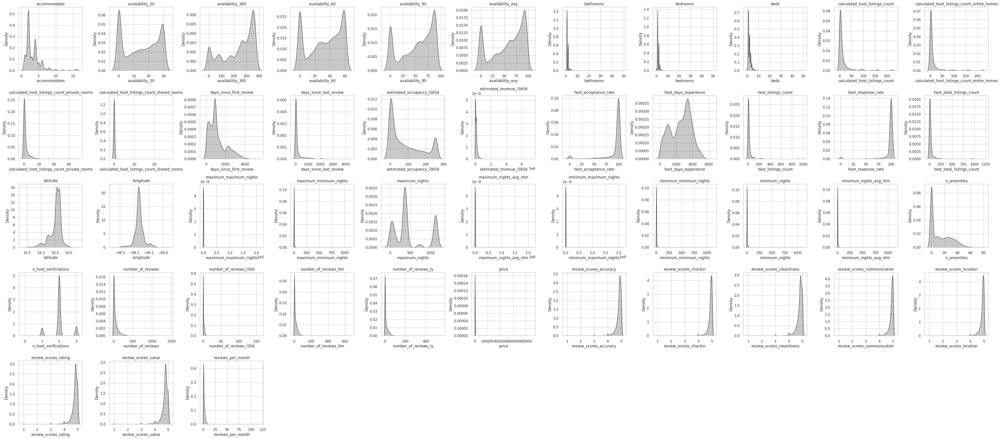

In [33]:
# Distribución de variables numéricas
plt.figure(figsize=(45, 20))
for i, col in enumerate(var_num):
    plt.subplot(5, 11, i+1)
    # sns.histplot(x = col, data = df_resumen, color = '#243a69')
    sns.kdeplot(x = col, data = df_resumen, color = color1, fill = True)
    plt.title(f'{col}')
    plt.tight_layout()

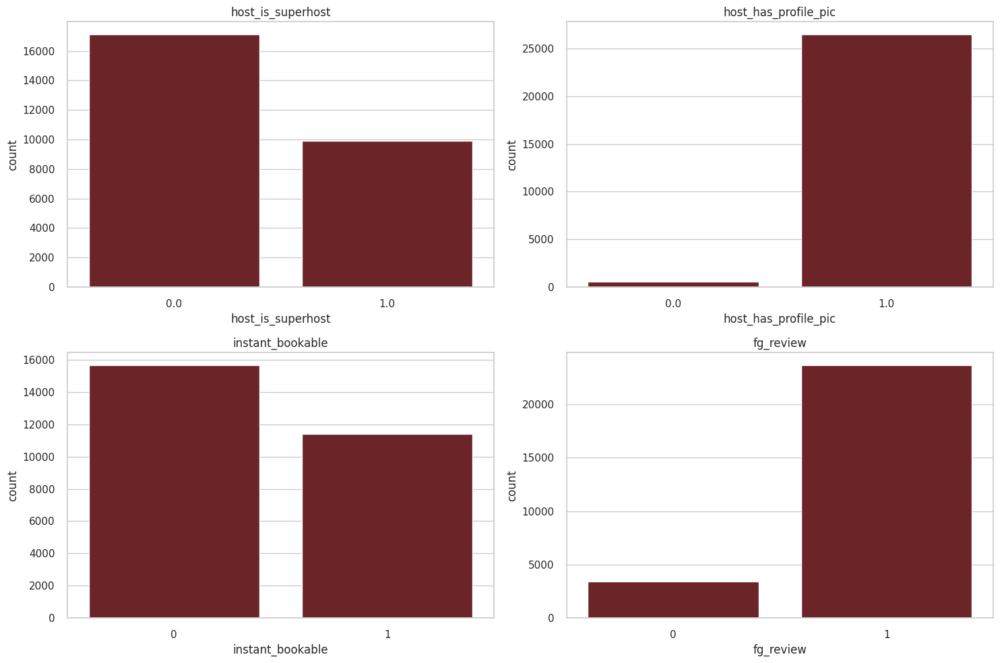

In [34]:
# Variables Binarias
plt.figure(figsize=(15, 10))
for i, col in enumerate(var_bin):
    df_aux = df_resumen[col].value_counts().reset_index()
    plt.subplot(2, 2, i+1)
    sns.barplot(x=col, y='count', data=df_aux, color=color2)
    plt.title(f'{col}')
    plt.tight_layout()

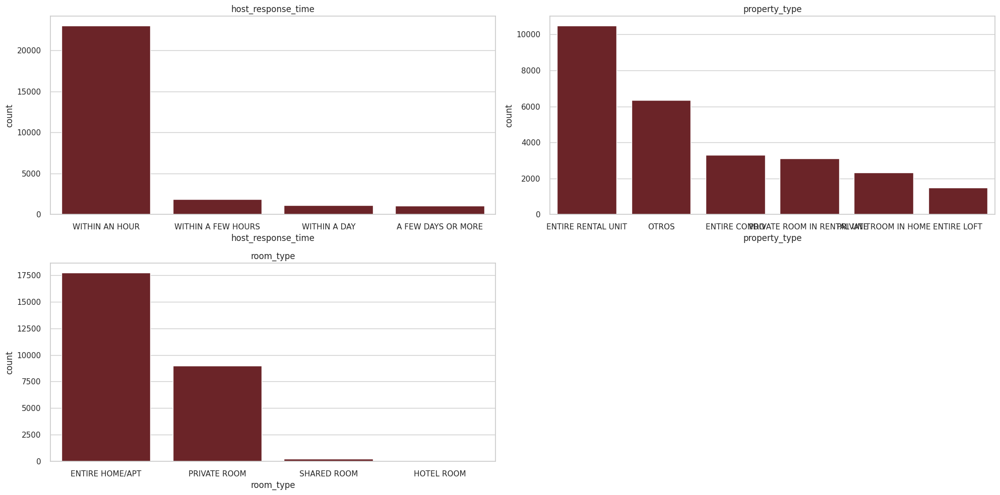

In [35]:
# Variables Categóricas
plt.figure(figsize=(20, 10))
for i, col in enumerate(var_cat):
    df_aux = df_resumen[col].value_counts().reset_index()
    plt.subplot(2, 2, i+1)
    sns.barplot(x=col, y='count', data=df_aux, color=color2)
    plt.title(f'{col}')
    plt.tight_layout()

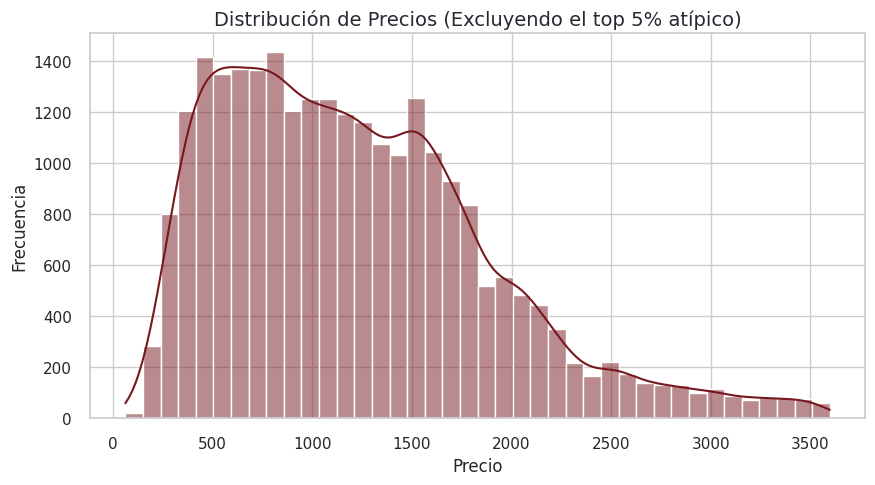

In [36]:
# Distrubución del Precio
# Se filtra el 5% de los precios más altos.
limite_precio = df_resumen['price'].quantile(0.95)
df_precio_filtrado = df_resumen[df_resumen['price'] < limite_precio]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_precio_filtrado['price'], kde=True, color=color2, bins=40, ax=ax)
ax.set_title('Distribución de Precios (Excluyendo el top 5% atípico)', fontsize=14, color=color1)
ax.set_xlabel('Precio', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
plt.show()

#### Distribución de tipo de alojamiento

/tmp/ipykernel_1232/3312066728.py:3: UserWarning:

The palette list has more values (5) than needed (4), which may not be intended.



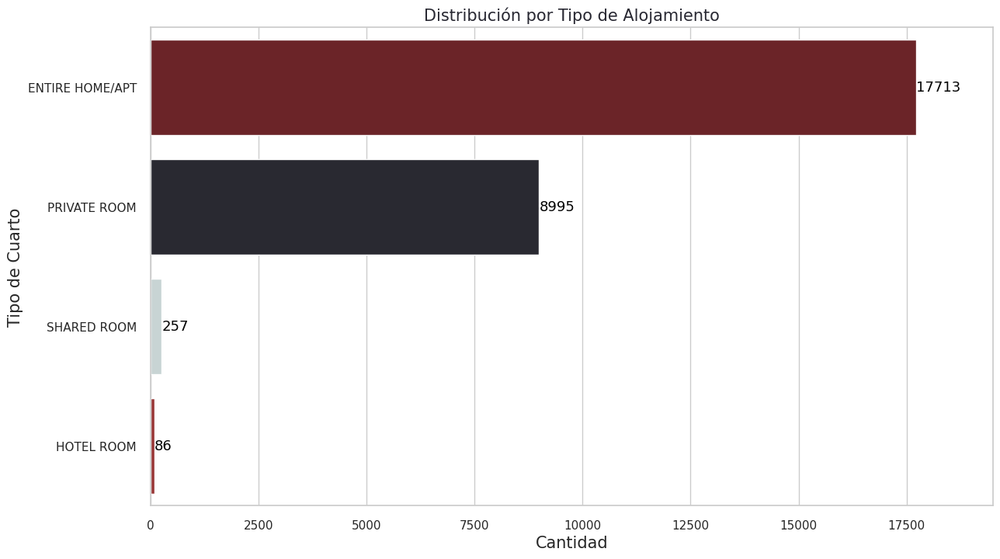

In [37]:
# Distribución de Room Type
fig, ax = plt.subplots(figsize=(14, 8))
sns.countplot(data=df_resumen, y='room_type', hue = 'room_type', palette=custom_palette, 
              order=df_resumen['room_type'].value_counts().index, ax=ax)
ax.set_title('Distribución por Tipo de Alojamiento', fontsize=15, color=color1)
ax.set_xlabel('Cantidad', fontsize=15)

for i in range(4):
    ax.bar_label(ax.containers[i], label_type='edge', color='black', fontsize=13)
ax.set_ylabel('Tipo de Cuarto', fontsize=15)
ax.set_xlim(0,19500)
plt.show()

#### Precio vs Tipo de Alojamiento

/tmp/ipykernel_1232/1331475578.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1232/1331475578.py:3: UserWarning:

The palette list has more values (5) than needed (4), which may not be intended.



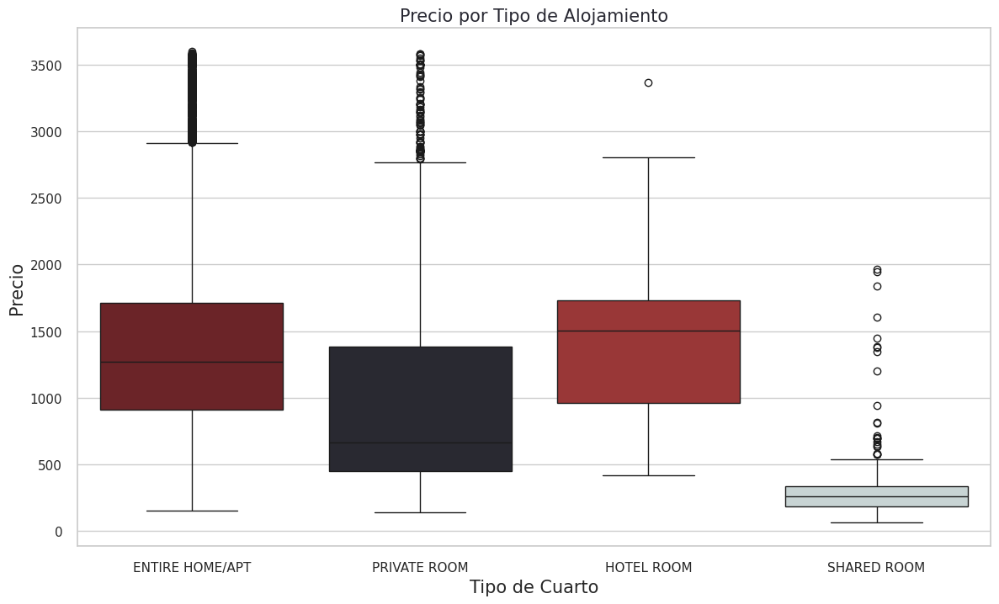

In [38]:
# Precio vs. Tipo de Alojamiento (Boxplot)
fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=df_precio_filtrado, x='room_type', y = 'price', palette=custom_palette, ax=ax)
ax.set_title('Precio por Tipo de Alojamiento', fontsize=15, color=color1)
ax.set_xlabel('Tipo de Cuarto', fontsize=15)
ax.set_ylabel('Precio', fontsize=15)
plt.show()

#### Capacidad de alojamiento vs. precio

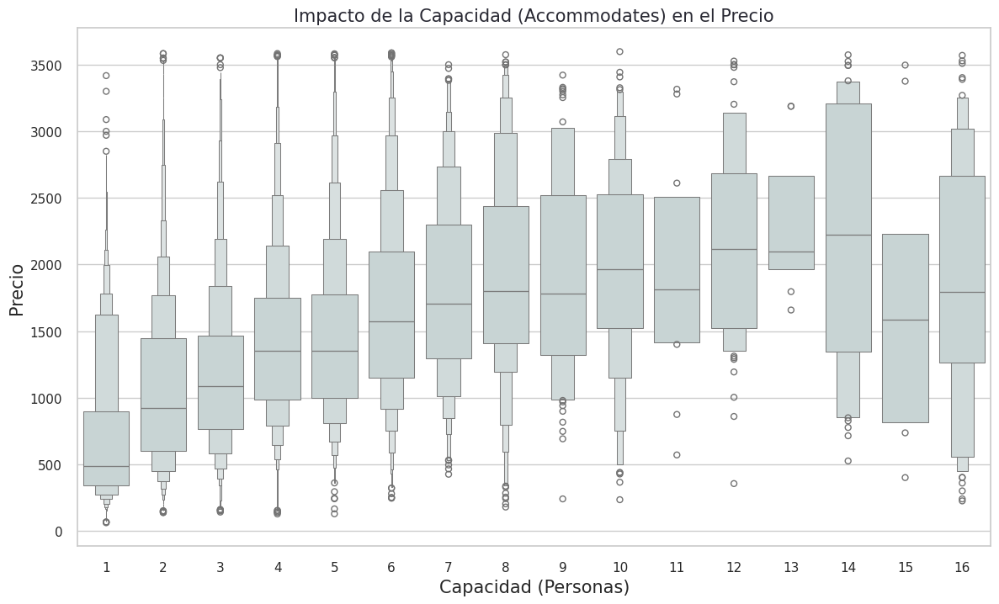

In [39]:
# 2.2 Capacidad vs Precio (Relación)
fig, ax = plt.subplots(figsize=(14, 8))
sns.boxenplot(data=df_precio_filtrado, x='accommodates', y='price', color=color4, ax=ax)
ax.set_title('Impacto de la Capacidad (Accommodates) en el Precio', fontsize=15, color=color1)
ax.set_xlabel('Capacidad (Personas)', fontsize=15)
ax.set_ylabel('Precio', fontsize=15)
plt.show()

#### Distribución de Precios y Reseñas Ciudad de México

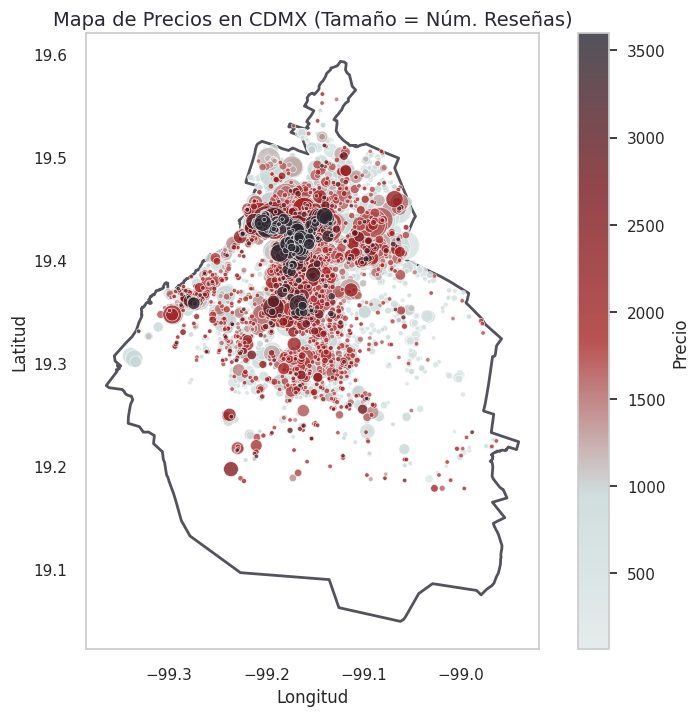

In [40]:
# Distribución de precios y reseñas en la CDMX
fig, ax = plt.subplots(figsize=(10, 8))

df_mapa = df_precio_filtrado.sort_values('price') 
scatter = ax.scatter(x=df_mapa['longitude'], y=df_mapa['latitude'], 
                     c=df_mapa['price'], cmap=cmap_custom, 
                     s=df_mapa['number_of_reviews'] * 0.5 + 10, # Tamaño según número de reviews
                     alpha=0.8, edgecolors='w', linewidth=0.5, zorder=5)

plt.colorbar(scatter, label='Precio')
ax.set_title('Mapa de Precios en CDMX (Tamaño = Núm. Reseñas)', fontsize=14, color=color1)
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)


ax.grid(False) 

# Contorno CDMX
cdmx_boundary = ox.geocode_to_gdf("Ciudad de México, México")
# Graficar contorno
cdmx_boundary.plot(ax=ax, facecolor='none', edgecolor=color1, linewidth=2, alpha=0.8)

plt.show()

#### Precio Promedio Tipo de Cuarto vs Superhost

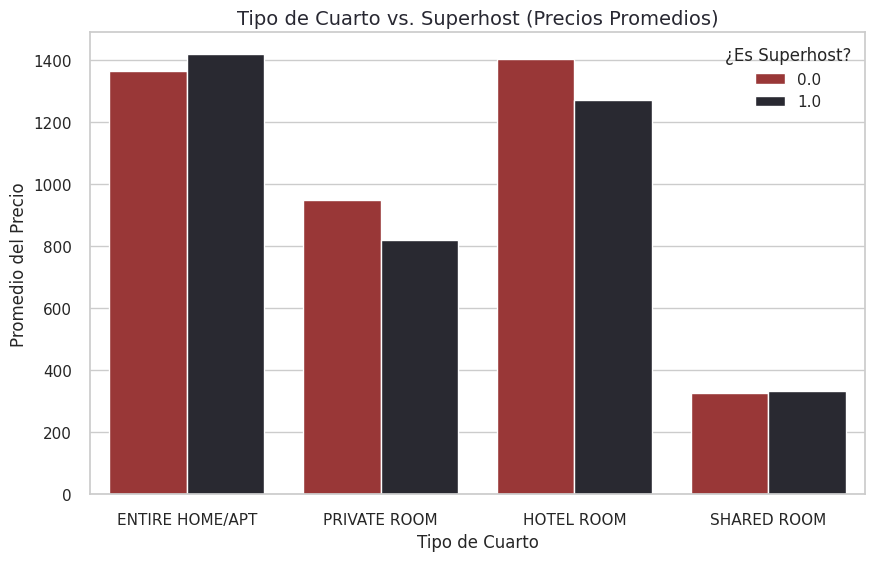

In [41]:
# 3.1 Precio según Tipo de Cuarto y Estatus de Superhost
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_precio_filtrado, x='room_type', y='price', hue='host_is_superhost', 
            palette=[color3, color1], estimator=np.mean, errorbar=None, ax=ax)
ax.set_title('Tipo de Cuarto vs. Superhost (Precios Promedios)', fontsize=14, color=color1)
ax.set_xlabel('Tipo de Cuarto', fontsize=12)
ax.set_ylabel('Promedio del Precio', fontsize=12)
plt.legend(title='¿Es Superhost?')
plt.show()

#### Tratamiento de Outliers

In [42]:
# Columnas numéricas solamente
df_numeric = df_resumen.select_dtypes(include=['number'])

skewness = (
    df_numeric
    .skew()
    .sort_values(ascending=False)
    .to_frame('skew')
)

cols_skewed = skewness.query('skew > 2').index.tolist()

print(cols_skewed)

mask = pd.Series(True, index=df_resumen.index)

for col in cols_skewed:
    q99 = df_resumen[col].quantile(0.99)
    mask &= df_resumen[col] <= q99

df_resumen_sin_outliers = df_resumen[mask].copy()

print(f"Antes: {df_resumen.shape[0]}")
print(f"Después: {df_resumen_sin_outliers.shape[0]}")

['price', 'maximum_nights_avg_ntm', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_minimum_nights', 'minimum_nights_avg_ntm', 'minimum_nights', 'maximum_minimum_nights', 'number_of_reviews_l30d', 'bedrooms', 'bathrooms', 'reviews_per_month', 'calculated_host_listings_count_shared_rooms', 'estimated_revenue_l365d', 'host_listings_count', 'beds', 'host_total_listings_count', 'number_of_reviews_ltm', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_entire_homes', 'number_of_reviews_ly', 'calculated_host_listings_count', 'days_since_last_review', 'number_of_reviews', 'accommodates']
Antes: 27051
Después: 24263


Se eliminan outliers por arriba del Q99 para variables con colas pesadas

In [43]:
def remove_outliers_knn_unsupervised(df, n_neighbors=5, method='largest', contamination=0.05):
    print(f"Dimensión del Dataset original: {df.shape[0]}")
    
    # Columnas numéricas solamente
    df_numeric = df.select_dtypes(include=['number'])
    
    # Escalamiento temporal
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df_numeric)
    
    model = KNN(n_neighbors=n_neighbors, method=method, contamination=contamination)
    model.fit(df_scaled)
    preds = model.predict(df_scaled)
    df_clean = df[preds == 0].copy()

    outliers_eliminados = sum(preds == 1)
    print(f"Se eliminaron {outliers_eliminados} outliers del dataset.")
    print(f"Dimensión del Dataset final: {df_clean.shape[0]}")
    
    return df_clean

df_resumen_sin_outliers = remove_outliers_knn_unsupervised(df_resumen_sin_outliers, n_neighbors=5, contamination=0.02)

df_resumen_sin_outliers.head()

Dimensión del Dataset original: 24263
Se eliminaron 430 outliers del dataset.
Dimensión del Dataset final: 23833


,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_days_experience,days_since_first_review,days_since_last_review,n_amenities,n_host_verifications,fg_review
0,WITHIN AN HOUR,100.00,100.00,0.00,1,1,1.00,19.38,-99.27,OTROS,ENTIRE HOME/APT,2,1,1,1,3673,1,7,1,1,7,7,1.00,7.00,28,58,88,363,0,0,0,94,0,0,0,4.84,4.88,4.85,4.92,4.92,4.92,4.80,0,1,1,0,0,0.00,5571,908.00,28.00,12,3,0
2,WITHIN A DAY,100.00,100.00,1.00,1,5,1.00,19.44,-99.16,ENTIRE CONDO,ENTIRE HOME/APT,2,1,1,1,591,15,250,15,15,250,250,15.00,250.00,0,28,58,333,84,1,0,63,0,30,17730,4.87,4.95,4.88,4.98,4.94,4.76,4.79,0,1,1,0,0,0.48,5458,"5,293.00",213.00,28,2,1
3,WITHIN A FEW HOURS,88.00,43.00,0.00,3,4,1.00,19.41,-99.17,ENTIRE RENTAL UNIT,ENTIRE HOME/APT,4,2,2,3,1090,2,30,2,2,30,30,2.00,30.00,0,9,9,252,50,1,0,9,4,6,137397,4.90,4.82,4.76,4.94,4.92,4.98,4.92,0,2,2,0,0,0.30,5381,"5,064.00",333.00,21,2,1
4,WITHIN A FEW HOURS,100.00,89.00,1.00,3,4,1.00,19.35,-99.16,ENTIRE RENTAL UNIT,ENTIRE HOME/APT,2,1,1,1,1064,3,180,3,4,180,180,3.40,180.00,4,19,49,234,134,8,0,51,9,48,116373,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0,3,2,1,0,0.81,5514,"4,975.00",41.00,50,3,1
5,WITHIN AN HOUR,100.00,100.00,0.00,3,4,1.00,19.35,-99.16,OTROS,PRIVATE ROOM,2,2,2,3,1121,1,730,1,1,730,730,1.00,730.00,0,0,0,0,0,0,0,0,0,0,137586,4.84,4.88,4.85,4.92,4.92,4.92,4.80,0,3,1,2,0,0.00,5234,908.00,28.00,10,1,0


Se aplica KNN para todo el dataset restante.

In [44]:
# def remove_outliers_quantiles(df, lower_q=0, upper_q=0.99):
#     print(f"Dimensión del Dataset original: {df.shape[0]}")

#     df_numeric = df.select_dtypes(include=['number'])

#     mask = pd.Series(True, index=df.index)

#     for col in df_numeric.columns:
#         lower = df_numeric[col].quantile(lower_q)
#         upper = df_numeric[col].quantile(upper_q)

#         mask &= df_numeric[col].between(lower, upper)

#     df_clean = df[mask].copy()

#     outliers_eliminados = (~mask).sum()

#     print(f"Se eliminaron {outliers_eliminados} registros.")
#     print(f"Dimensión del Dataset final: {df_clean.shape[0]}")

#     return df_clean

# df_resumen_sin_outliers = remove_outliers_quantiles(
#     df_resumen,
#     lower_q=0,
#     upper_q=0.99
# )

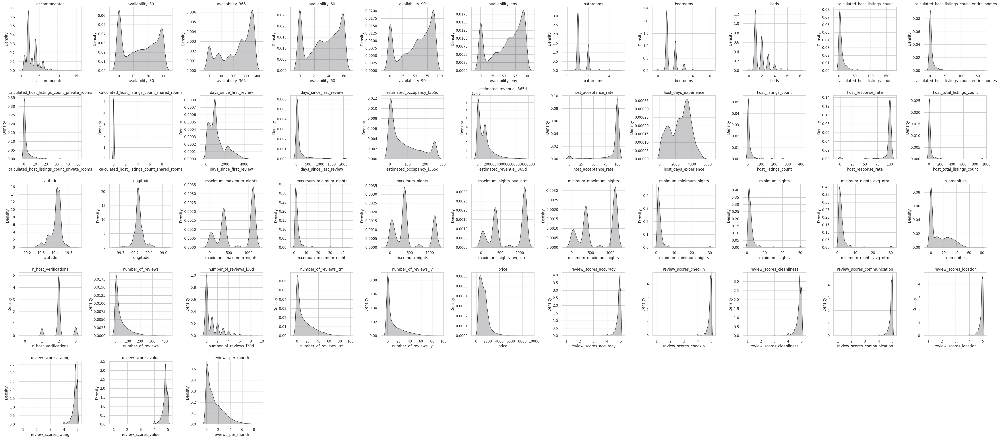

In [45]:
# Distribución de variables numéricas posterior al tratamiento de outliers
plt.figure(figsize=(45, 20))
for i, col in enumerate(var_num):
    plt.subplot(5, 11, i+1)
    # sns.histplot(x = col, data = df_resumen, color = '#243a69')
    sns.kdeplot(x = col, data = df_resumen_sin_outliers, color = color1, fill = True)
    plt.title(f'{col}')
    plt.tight_layout()

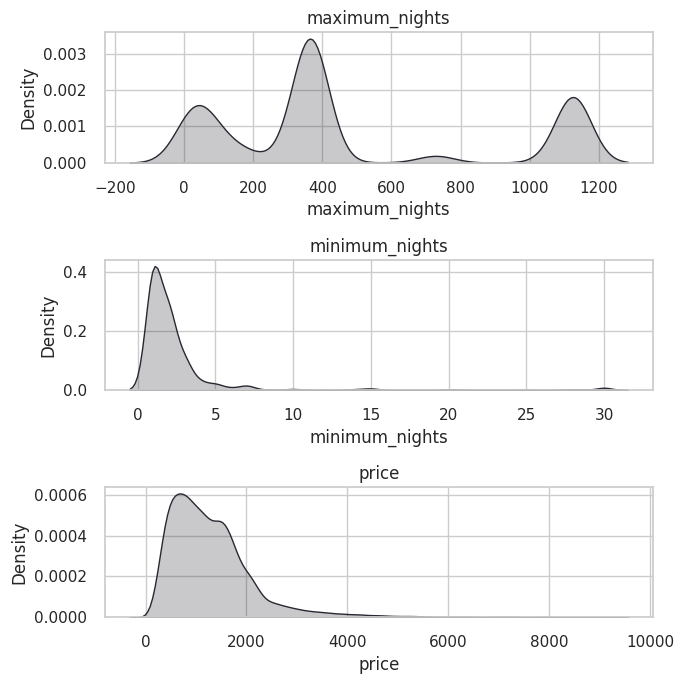

In [46]:
# Distribución de variables numéricas posterior al tratamiento de outliers
plt.figure(figsize=(7, 7))
for i, col in enumerate(["maximum_nights", "minimum_nights", "price"]):
    plt.subplot(3, 1, i+1)
    # sns.histplot(x = col, data = df_resumen, color = '#243a69')
    sns.kdeplot(x = col, data = df_resumen_sin_outliers, color = color1, fill = True)
    plt.title(f'{col}')
    plt.tight_layout()

Se observa una mejor distribución para las variables como "maximum_nights", "minimum_nights", "price", entre otras.

#### Correlaciones

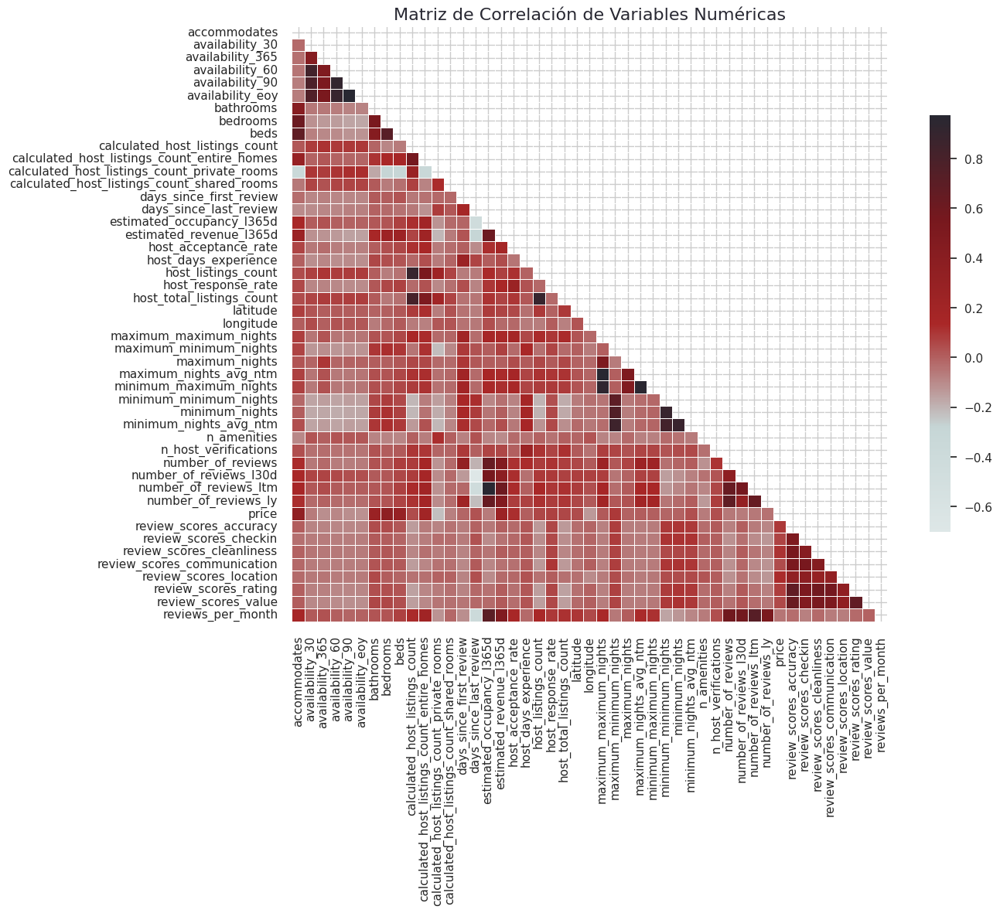

In [47]:
# Matriz de Correlación
# Solo Columnas Numéricas
df_numerico = df_resumen_sin_outliers[var_num]
corr = df_numerico.corr('kendall')

# Se borra la parte superior
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, cmap=cmap_custom, square=True, linewidths=.5, cbar_kws={"shrink": .7})
ax.set_title('Matriz de Correlación de Variables Numéricas', fontsize=16, color=color1)
plt.show()

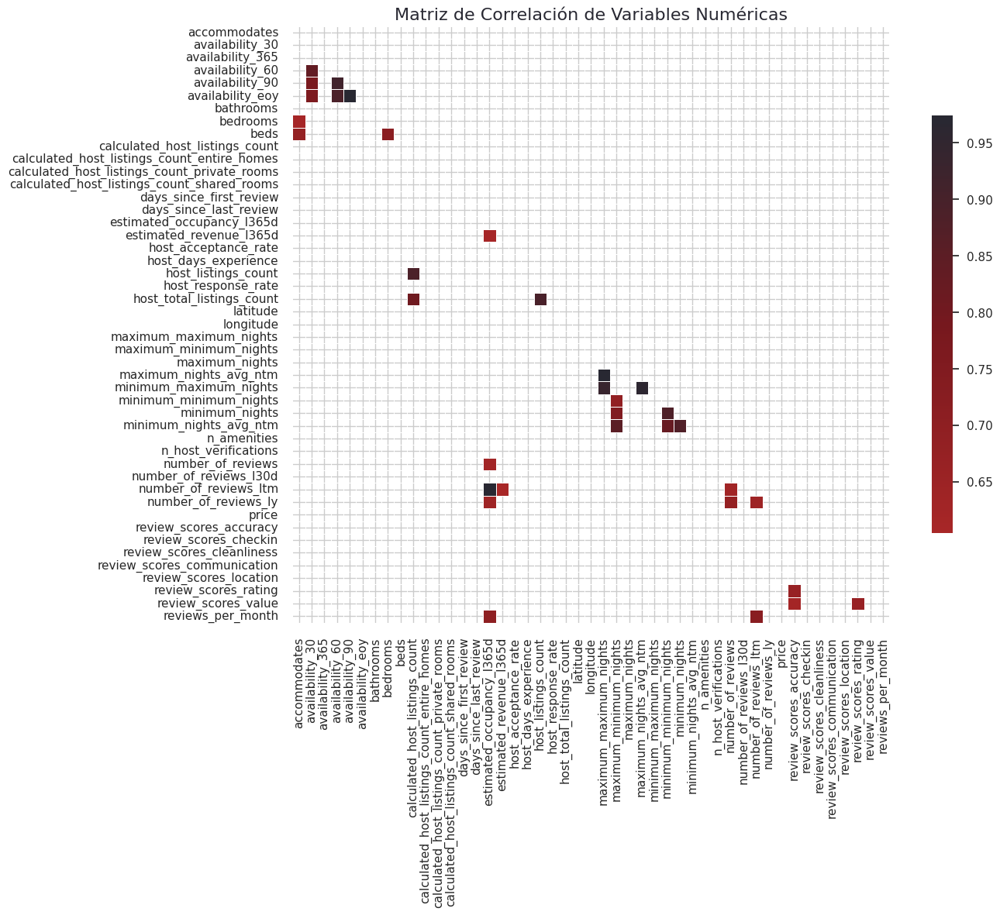

In [48]:
mask = np.triu(np.ones_like(corr[corr >= 0.6], dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr[corr >= 0.6], mask = mask, cmap=cmap_custom, square=True, linewidths=.5, cbar_kws={"shrink": .7}, center = 0.6)
ax.set_title('Matriz de Correlación de Variables Numéricas', fontsize=16, color=color1)
plt.show()

#### Escalamiento y Codificación

In [49]:
resumen(df_resumen_sin_outliers,5)

Total de filas: 23833 
Total de columnas: 54 
Total de elementos: 1286982


,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_days_experience,days_since_first_review,days_since_last_review,n_amenities,n_host_verifications,fg_review
0,WITHIN AN HOUR,100.00,100.00,0.00,1,1,1.00,19.38,-99.27,OTROS,ENTIRE HOME/APT,2,1,1,1,3673,1,7,1,1,7,7,1.00,7.00,28,58,88,363,0,0,0,94,0,0,0,4.84,4.88,4.85,4.92,4.92,4.92,4.80,0,1,1,0,0,0.00,5571,908.00,28.00,12,3,0
2,WITHIN A DAY,100.00,100.00,1.00,1,5,1.00,19.44,-99.16,ENTIRE CONDO,ENTIRE HOME/APT,2,1,1,1,591,15,250,15,15,250,250,15.00,250.00,0,28,58,333,84,1,0,63,0,30,17730,4.87,4.95,4.88,4.98,4.94,4.76,4.79,0,1,1,0,0,0.48,5458,"5,293.00",213.00,28,2,1
3,WITHIN A FEW HOURS,88.00,43.00,0.00,3,4,1.00,19.41,-99.17,ENTIRE RENTAL UNIT,ENTIRE HOME/APT,4,2,2,3,1090,2,30,2,2,30,30,2.00,30.00,0,9,9,252,50,1,0,9,4,6,137397,4.90,4.82,4.76,4.94,4.92,4.98,4.92,0,2,2,0,0,0.30,5381,"5,064.00",333.00,21,2,1
4,WITHIN A FEW HOURS,100.00,89.00,1.00,3,4,1.00,19.35,-99.16,ENTIRE RENTAL UNIT,ENTIRE HOME/APT,2,1,1,1,1064,3,180,3,4,180,180,3.40,180.00,4,19,49,234,134,8,0,51,9,48,116373,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0,3,2,1,0,0.81,5514,"4,975.00",41.00,50,3,1
5,WITHIN AN HOUR,100.00,100.00,0.00,3,4,1.00,19.35,-99.16,OTROS,PRIVATE ROOM,2,2,2,3,1121,1,730,1,1,730,730,1.00,730.00,0,0,0,0,0,0,0,0,0,0,137586,4.84,4.88,4.85,4.92,4.92,4.92,4.80,0,3,1,2,0,0.00,5234,908.00,28.00,10,1,0


In [50]:
# Transformador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), var_num), 
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), var_cat)
    ],
    remainder='passthrough'
)

preprocessor.set_output(transform="pandas")
df_scaled = preprocessor.fit_transform(df_resumen_sin_outliers)

print(f"Dimensiones del nuevo DataFrame: {df_scaled.shape}")
display(df_scaled.head())

Dimensiones del nuevo DataFrame: (23833, 65)


,num__accommodates,num__availability_30,num__availability_365,num__availability_60,num__availability_90,num__availability_eoy,num__bathrooms,num__bedrooms,num__beds,num__calculated_host_listings_count,num__calculated_host_listings_count_entire_homes,num__calculated_host_listings_count_private_rooms,num__calculated_host_listings_count_shared_rooms,num__days_since_first_review,num__days_since_last_review,num__estimated_occupancy_l365d,num__estimated_revenue_l365d,num__host_acceptance_rate,num__host_days_experience,num__host_listings_count,num__host_response_rate,num__host_total_listings_count,num__latitude,num__longitude,num__maximum_maximum_nights,num__maximum_minimum_nights,num__maximum_nights,num__maximum_nights_avg_ntm,num__minimum_maximum_nights,num__minimum_minimum_nights,num__minimum_nights,num__minimum_nights_avg_ntm,num__n_amenities,num__n_host_verifications,num__number_of_reviews,num__number_of_reviews_l30d,num__number_of_reviews_ltm,num__number_of_reviews_ly,num__price,num__review_scores_accuracy,num__review_scores_checkin,num__review_scores_cleanliness,num__review_scores_communication,num__review_scores_location,num__review_scores_rating,num__review_scores_value,num__reviews_per_month,cat__host_response_time_A FEW DAYS OR MORE,cat__host_response_time_WITHIN A DAY,cat__host_response_time_WITHIN A FEW HOURS,cat__host_response_time_WITHIN AN HOUR,cat__property_type_ENTIRE CONDO,cat__property_type_ENTIRE LOFT,cat__property_type_ENTIRE RENTAL UNIT,cat__property_type_OTROS,cat__property_type_PRIVATE ROOM IN HOME,cat__property_type_PRIVATE ROOM IN RENTAL UNIT,cat__room_type_ENTIRE HOME/APT,cat__room_type_HOTEL ROOM,cat__room_type_PRIVATE ROOM,cat__room_type_SHARED ROOM,remainder__host_is_superhost,remainder__host_has_profile_pic,remainder__instant_bookable,remainder__fg_review
0,-0.63,1.20,1.09,1.21,1.12,1.15,-0.60,-0.64,-0.73,-0.43,-0.34,-0.42,-0.09,-0.25,-0.39,-0.94,-0.86,0.41,2.37,-0.40,0.29,-0.26,-0.53,-3.18,-1.58,-0.46,-1.17,-1.56,-1.51,-0.37,-0.39,-0.41,-0.09,2.09,-0.73,-0.67,-0.83,-0.71,2.50,0.24,0.25,0.23,0.25,0.26,0.20,0.18,-0.97,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0,0
2,-0.63,-1.34,0.84,-0.21,0.16,0.21,-0.60,-0.64,-0.73,-0.43,-0.34,-0.42,-0.09,4.63,0.15,-0.59,-0.72,0.41,2.28,-0.40,0.29,-0.22,0.82,0.27,-1.03,2.94,-0.56,-1.01,-0.97,3.48,3.29,3.31,0.96,-0.03,0.54,-0.67,-0.77,-0.71,-0.78,0.53,0.54,0.34,0.34,-0.51,0.32,0.14,-0.66,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0,1
3,0.46,-1.34,0.18,-1.10,-1.40,-1.43,1.06,0.72,1.04,-0.39,-0.29,-0.42,-0.09,4.38,0.51,-0.87,0.23,-2.07,2.22,-0.34,-0.36,-0.23,0.15,-0.10,-1.53,-0.21,-1.12,-1.51,-1.46,-0.09,-0.13,-0.15,0.50,-0.03,0.02,-0.67,-0.77,-0.46,-0.24,-0.01,0.34,-0.11,0.25,0.55,0.44,0.63,-0.77,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0,1
4,-0.63,-0.97,0.03,-0.63,-0.12,-0.16,-0.60,-0.64,-0.73,-0.35,-0.29,-0.24,-0.09,4.28,-0.36,-0.38,0.07,-0.07,2.32,-0.34,0.29,-0.23,-1.20,0.09,-1.19,0.27,-0.74,-1.17,-1.12,0.18,0.14,0.23,2.39,2.09,1.29,-0.67,-0.36,-0.16,-0.27,0.32,0.44,0.65,0.51,0.45,0.48,0.63,-0.44,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0,1
5,-0.63,-1.34,-1.88,-1.53,-1.69,-1.71,1.06,0.72,1.04,-0.35,-0.34,-0.06,-0.09,-0.25,-0.39,-0.94,0.23,0.41,2.10,-0.34,0.29,-0.23,-1.20,0.01,0.07,-0.46,0.65,0.09,0.12,-0.37,-0.39,-0.41,-0.22,-2.16,-0.73,-0.67,-0.83,-0.71,-0.21,0.24,0.25,0.23,0.25,0.26,0.20,0.18,-0.97,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0,0


In [51]:
# Lista de columnas a eliminar
columnas_corr = ['num__availability_60',
 'num__availability_90',
 'num__availability_eoy',
 'num__beds',
 'num__estimated_revenue_l365d',
 'num__host_listings_count',
 'num__host_total_listings_count',
 'num__maximum_nights_avg_ntm',
 'num__minimum_maximum_nights',
 'num__minimum_minimum_nights',
 'num__minimum_nights_avg_ntm',
 'num__number_of_reviews_ltm',
 'num__number_of_reviews_ly',
 'num__review_scores_rating',
 'num__reviews_per_month']

In [52]:
df_scaled_sin_corr = df_scaled.drop(columns=columnas_corr)
resumen(df_scaled_sin_corr,5)

Total de filas: 23833 
Total de columnas: 50 
Total de elementos: 1191650


,num__accommodates,num__availability_30,num__availability_365,num__bathrooms,num__bedrooms,num__calculated_host_listings_count,num__calculated_host_listings_count_entire_homes,num__calculated_host_listings_count_private_rooms,num__calculated_host_listings_count_shared_rooms,num__days_since_first_review,num__days_since_last_review,num__estimated_occupancy_l365d,num__host_acceptance_rate,num__host_days_experience,num__host_response_rate,num__latitude,num__longitude,num__maximum_maximum_nights,num__maximum_minimum_nights,num__maximum_nights,num__minimum_nights,num__n_amenities,num__n_host_verifications,num__number_of_reviews,num__number_of_reviews_l30d,num__price,num__review_scores_accuracy,num__review_scores_checkin,num__review_scores_cleanliness,num__review_scores_communication,num__review_scores_location,num__review_scores_value,cat__host_response_time_A FEW DAYS OR MORE,cat__host_response_time_WITHIN A DAY,cat__host_response_time_WITHIN A FEW HOURS,cat__host_response_time_WITHIN AN HOUR,cat__property_type_ENTIRE CONDO,cat__property_type_ENTIRE LOFT,cat__property_type_ENTIRE RENTAL UNIT,cat__property_type_OTROS,cat__property_type_PRIVATE ROOM IN HOME,cat__property_type_PRIVATE ROOM IN RENTAL UNIT,cat__room_type_ENTIRE HOME/APT,cat__room_type_HOTEL ROOM,cat__room_type_PRIVATE ROOM,cat__room_type_SHARED ROOM,remainder__host_is_superhost,remainder__host_has_profile_pic,remainder__instant_bookable,remainder__fg_review
0,-0.63,1.20,1.09,-0.60,-0.64,-0.43,-0.34,-0.42,-0.09,-0.25,-0.39,-0.94,0.41,2.37,0.29,-0.53,-3.18,-1.58,-0.46,-1.17,-0.39,-0.09,2.09,-0.73,-0.67,2.50,0.24,0.25,0.23,0.25,0.26,0.18,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0,0
2,-0.63,-1.34,0.84,-0.60,-0.64,-0.43,-0.34,-0.42,-0.09,4.63,0.15,-0.59,0.41,2.28,0.29,0.82,0.27,-1.03,2.94,-0.56,3.29,0.96,-0.03,0.54,-0.67,-0.78,0.53,0.54,0.34,0.34,-0.51,0.14,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0,1
3,0.46,-1.34,0.18,1.06,0.72,-0.39,-0.29,-0.42,-0.09,4.38,0.51,-0.87,-2.07,2.22,-0.36,0.15,-0.10,-1.53,-0.21,-1.12,-0.13,0.50,-0.03,0.02,-0.67,-0.24,-0.01,0.34,-0.11,0.25,0.55,0.63,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0,1
4,-0.63,-0.97,0.03,-0.60,-0.64,-0.35,-0.29,-0.24,-0.09,4.28,-0.36,-0.38,-0.07,2.32,0.29,-1.20,0.09,-1.19,0.27,-0.74,0.14,2.39,2.09,1.29,-0.67,-0.27,0.32,0.44,0.65,0.51,0.45,0.63,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0,1
5,-0.63,-1.34,-1.88,1.06,0.72,-0.35,-0.34,-0.06,-0.09,-0.25,-0.39,-0.94,0.41,2.10,0.29,-1.20,0.01,0.07,-0.46,0.65,-0.39,-0.22,-2.16,-0.73,-0.67,-0.21,0.24,0.25,0.23,0.25,0.26,0.18,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0,0


___

## 📄 2. Reducción de Dimensiones (PCA)

### PCA

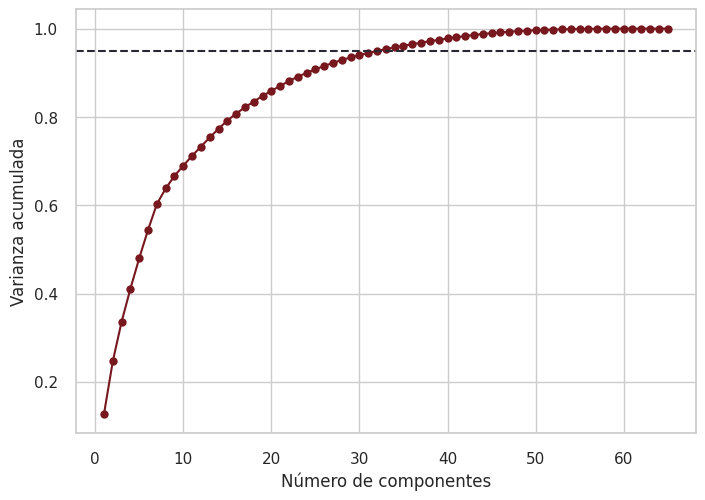

In [53]:
pca_full = PCA()
pca_full.fit(df_scaled)

cum_var = np.cumsum(
    pca_full.explained_variance_ratio_
)

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    color = color2,
    marker='o'
)

plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.axhline(
    y=0.95,
    color=color1,
    linestyle='--'
)

plt.show()

Se observa que con 32 componentes se explica el 95% de la varianza acumulada

In [54]:
pca_= PCA(n_components=3)

pca_.fit(df_scaled)

data_pca=pd.DataFrame(pca_.transform(df_scaled),columns=["PC1","PC2","PC3"])
varianza_total = pca_.explained_variance_ratio_.sum() * 100
print(f"La varianza total explicada con 3 componentes es {varianza_total:.2f}")
data_pca.head()

La varianza total explicada con 3 componentes es 33.65


,PC1,PC2,PC3
0,-2.28,-0.42,2.72
1,-3.04,3.29,-1.15
2,-1.58,2.95,-1.05
3,-0.76,2.20,0.34
4,-1.15,2.74,-1.91


In [55]:
# Visualización 3D
fig = px.scatter_3d(
    data_pca, 
    x='PC1', 
    y='PC2', 
    z='PC3', 
    labels={
        'PC1': 'Componente 1', 
        'PC2': 'Componente 2', 
        'PC3': 'Componente 3',
    }
)

fig.update_traces(
    marker=dict(
        size=5, 
        line=dict(width=1, color='Black')
    ),
    selector=dict(mode='markers')
)

fig.show()

In [56]:
pca_optimo= PCA(n_components=32)

pca_optimo.fit(df_scaled)

data_pca_optimo=pd.DataFrame(pca_optimo.transform(df_scaled),columns=[f"PC{x+1}" for x in range(32)])
varianza_total_optima = pca_optimo.explained_variance_ratio_.sum() * 100
print(f"La varianza total explicada con {32} componentes es {varianza_total_optima:.2f}")
data_pca_optimo.head()

La varianza total explicada con 32 componentes es 94.94


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32
0,-2.28,-0.42,2.72,1.47,-0.41,-0.15,0.22,1.69,4.11,-1.69,-2.57,0.30,0.79,1.00,0.99,0.12,-0.43,-0.10,0.41,0.14,-0.34,-1.11,0.19,0.65,0.13,0.37,0.80,-0.84,0.41,-0.07,-0.10,-0.44
1,-3.04,3.29,-1.15,-0.39,5.55,0.30,-1.23,2.26,2.26,-0.09,2.04,0.48,0.85,-1.74,-0.16,-1.68,0.31,0.82,0.29,1.25,0.01,-1.17,1.24,0.44,-0.04,0.34,-0.83,0.78,-0.23,0.05,-0.36,-0.55
2,-1.58,2.95,-1.05,0.62,-1.60,-1.35,0.10,4.43,0.85,0.52,1.07,0.07,0.38,-0.97,0.16,-1.70,0.42,0.25,0.62,0.93,0.81,-0.71,0.77,0.16,-1.15,-0.52,-0.97,0.83,-0.68,-0.09,-0.21,0.18
3,-0.76,2.20,0.34,-1.05,0.23,0.14,-1.41,3.71,3.09,0.21,1.37,-1.02,1.78,-0.57,1.22,-0.98,-1.43,0.89,-0.26,0.52,0.44,-0.60,1.21,0.22,-0.32,-0.39,-0.69,1.02,-0.60,-0.03,0.16,-0.00
4,-1.15,2.74,-1.91,-0.24,-2.55,-0.15,0.04,-0.36,-0.08,0.12,0.48,-1.16,-1.52,0.03,0.37,-1.21,-0.49,-1.60,2.03,-0.44,-0.99,-0.19,-0.67,-0.18,0.39,0.23,-0.61,-0.48,0.53,0.07,-0.14,0.37


## 📄 3. Número de Clusters Óptimos

### KMEAN con todas las variables 

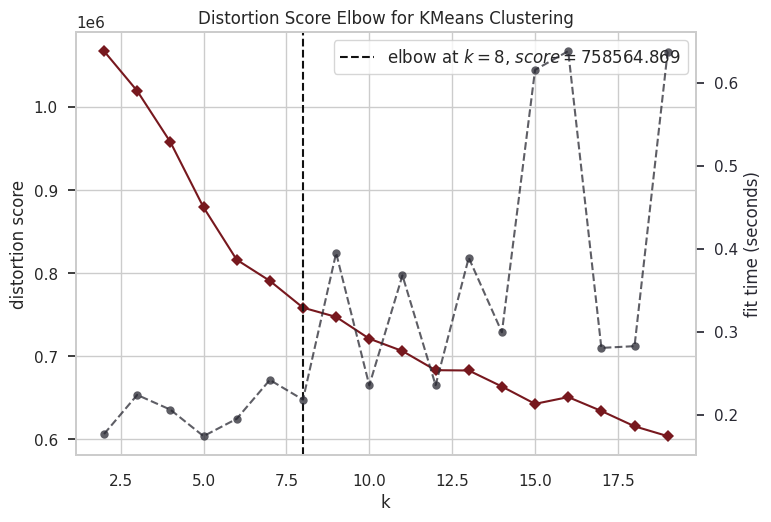

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [56]:
codo(df_scaled,2,20)

In [57]:
score_silueta(df_scaled,2,20,model_type="kmeans")

### KMEANS con PCA

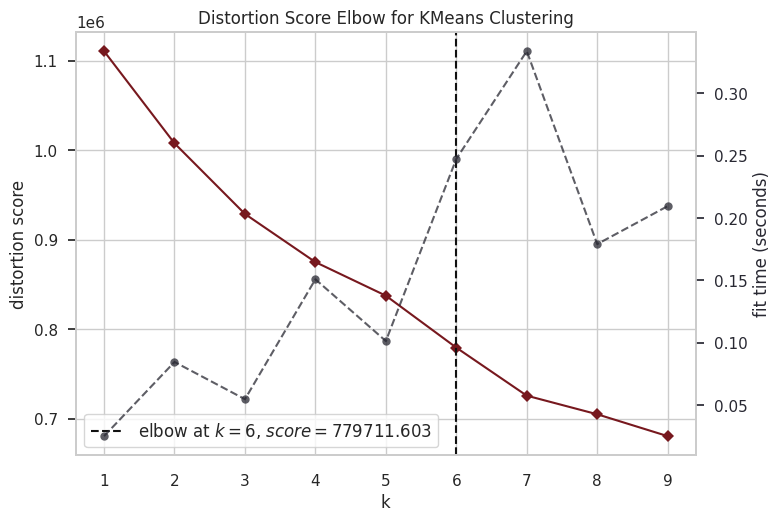

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [58]:
codo(data_pca_optimo,1,10)

In [59]:
score_silueta(data_pca_optimo,2,10,model_type="kmeans")

### GMM con todas las variables

In [60]:
score_silueta(df_scaled,2,10,model_type="gmm")

/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning:

Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.



In [61]:
codo_gmm_aic_bic(df_scaled,2,10)

/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning:

Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.



### GMM con PCA

In [62]:
score_silueta(data_pca_optimo,2,10,model_type="gmm")

/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning:

Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.



In [63]:
codo_gmm_aic_bic(data_pca_optimo,2,10)

/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning:

Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.



### Clúster Jerárquico con todas las variables

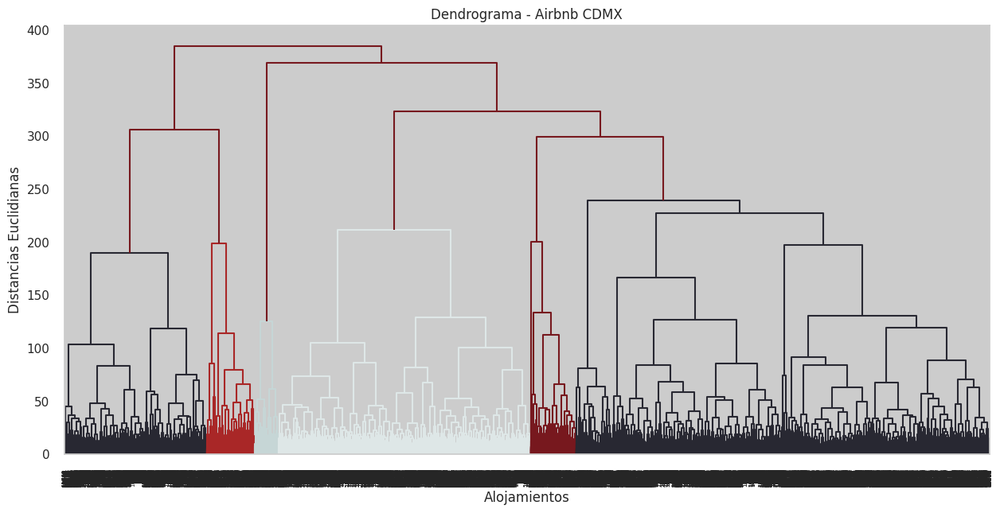

In [66]:
def graficar_dendrograma(X, title="Dendrograma - Airbnb CDMX"):
    plt.figure(figsize=(15, 7))
    plt.title(title)
    
    dendrograma = sch.dendrogram(sch.linkage(X, method='ward'))
    
    plt.xlabel('Alojamientos')
    plt.ylabel('Distancias Euclidianas')
    plt.show()

graficar_dendrograma(df_scaled)

In [65]:
score_silueta_jerarquico(df_scaled,2,10)

k=2 completado: Silhouette Score = 0.1041
k=3 completado: Silhouette Score = 0.1182
k=4 completado: Silhouette Score = 0.0544
k=5 completado: Silhouette Score = 0.0607
k=6 completado: Silhouette Score = 0.0671
k=7 completado: Silhouette Score = 0.0728
k=8 completado: Silhouette Score = 0.0600
k=9 completado: Silhouette Score = 0.0538


### Clúster Jerárquico con PCA

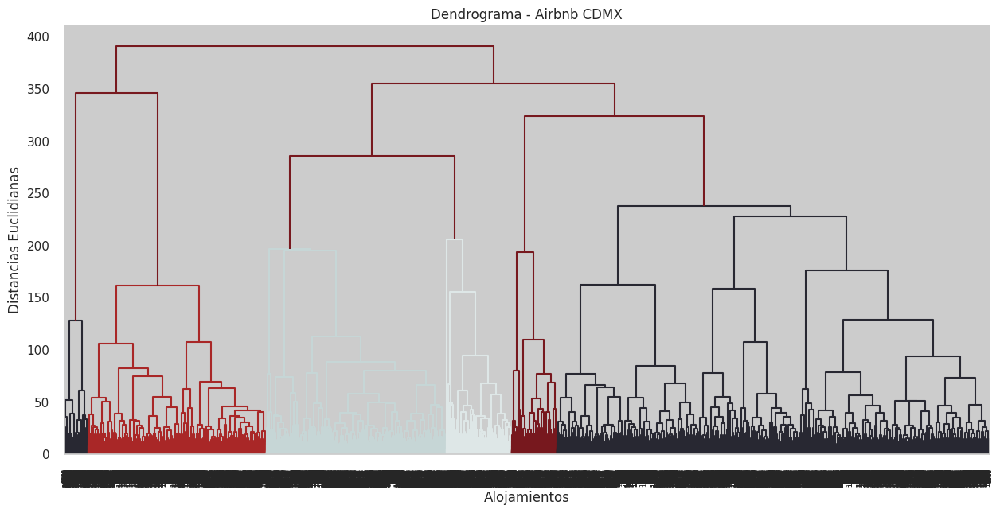

In [66]:
graficar_dendrograma(data_pca_optimo)

In [67]:
score_silueta_jerarquico(data_pca_optimo,2,10)

k=2 completado: Silhouette Score = 0.0957
k=3 completado: Silhouette Score = 0.0807
k=4 completado: Silhouette Score = 0.0768
k=5 completado: Silhouette Score = 0.0844
k=6 completado: Silhouette Score = 0.0845
k=7 completado: Silhouette Score = 0.0658
k=8 completado: Silhouette Score = 0.0630
k=9 completado: Silhouette Score = 0.0649


### DBSCAN con PCA

In [68]:
codo_dbscan_automatico(data_pca_optimo, min_samples=len(data_pca_optimo.columns))

Calculando distancias para 32 vecinos...


In [69]:
modelo = DBSCAN(eps=4.0, min_samples=len(data_pca_optimo.columns)).fit(data_pca_optimo)
etiquetas = modelo.labels_

# Número de clústers
n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)

print(f"n_clusters encontrados por DBSCAN: {n_clusters}.")

n_clusters encontrados por DBSCAN: 6.


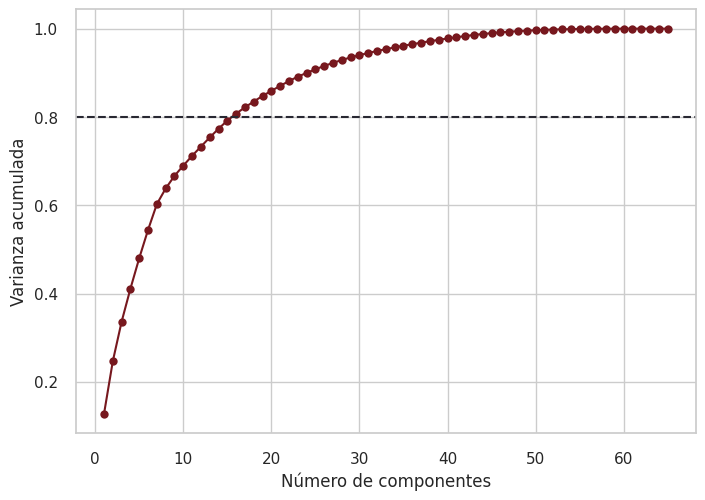

In [70]:
pca_full = PCA()
pca_full.fit(df_scaled)

cum_var = np.cumsum(
    pca_full.explained_variance_ratio_
)

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    color = color2,
    marker='o'
)

plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.axhline(
    y=0.80,
    color=color1,
    linestyle='--'
)

plt.show()

In [71]:
pca_optimo_dbscan= PCA(n_components=15)

pca_optimo_dbscan.fit(df_scaled)

data_pca_optimo_dbscan=pd.DataFrame(pca_optimo_dbscan.transform(df_scaled),columns=[f"PC{x+1}" for x in range(15)])
varianza_total_optima_dbscan = pca_optimo_dbscan.explained_variance_ratio_.sum() * 100
print(f"La varianza total explicada con {15} componentes es {varianza_total_optima:.2f}")
data_pca_optimo_dbscan.head()

La varianza total explicada con 15 componentes es 94.94


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,-2.28,-0.42,2.72,1.47,-0.41,-0.15,0.22,1.69,4.11,-1.69,-2.57,0.30,0.79,1.00,0.99
1,-3.04,3.29,-1.15,-0.39,5.55,0.30,-1.23,2.26,2.26,-0.09,2.04,0.48,0.85,-1.74,-0.16
2,-1.58,2.95,-1.05,0.62,-1.60,-1.35,0.10,4.43,0.85,0.52,1.07,0.07,0.38,-0.97,0.16
3,-0.76,2.20,0.34,-1.05,0.23,0.14,-1.41,3.71,3.09,0.21,1.37,-1.02,1.78,-0.57,1.22
4,-1.15,2.74,-1.91,-0.24,-2.55,-0.15,0.04,-0.36,-0.08,0.12,0.48,-1.16,-1.52,0.03,0.37


In [72]:
codo_dbscan_automatico(data_pca_optimo_dbscan, min_samples=len(data_pca_optimo_dbscan.columns))

Calculando distancias para 15 vecinos...


In [73]:
modelo = DBSCAN(eps=3.9, min_samples=len(data_pca_optimo_dbscan.columns)).fit(data_pca_optimo_dbscan)
etiquetas = modelo.labels_

# Número de clústers
n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)

print(f"n_clusters encontrados por DBSCAN: {n_clusters}.")

n_clusters encontrados por DBSCAN: 4.


### Visualización 2D

In [57]:
pca_2D= PCA(n_components=2)

pca_2D.fit(df_scaled)

data_pca_2D=pd.DataFrame(pca_2D.transform(df_scaled),columns=["PC1","PC2"])
varianza_total = pca_2D.explained_variance_ratio_.sum() * 100
print(f"La varianza total explicada con 3 componentes es {varianza_total:.2f}")
data_pca_2D.head()

La varianza total explicada con 3 componentes es 24.71


,PC1,PC2
0,-2.28,-0.42
1,-3.04,3.29
2,-1.58,2.95
3,-0.76,2.20
4,-1.15,2.74


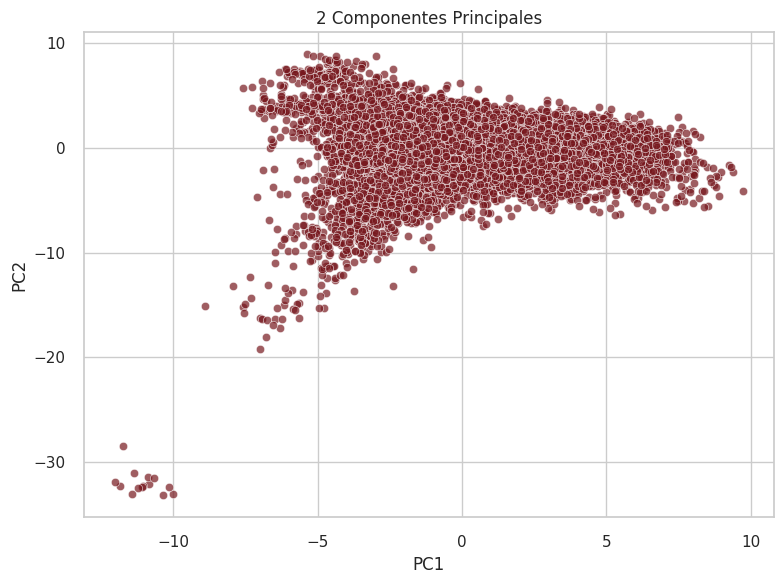

In [58]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data_pca_2D, x='PC1', y='PC2', alpha=0.7)
plt.title(f'2 Componentes Principales')
plt.tight_layout()
plt.show()

#### KMEANS

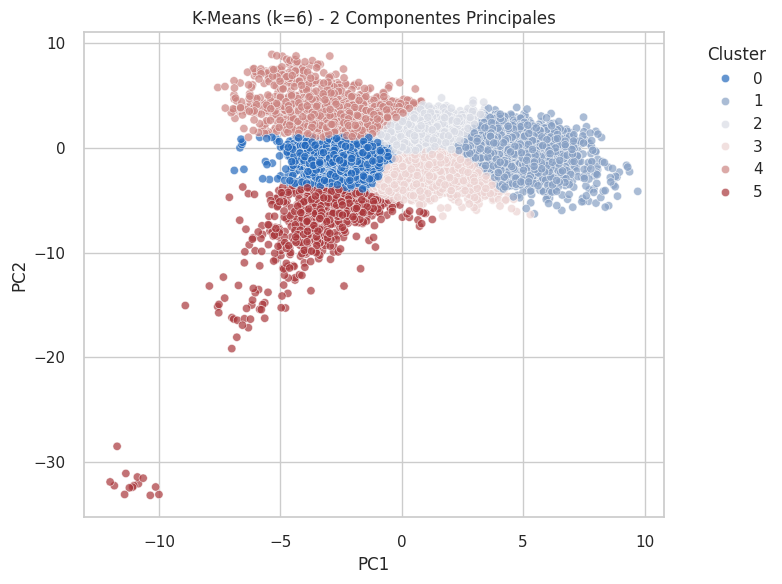

In [59]:
k_kmeans = 6
modelo_kmeans = KMeans(n_clusters=k_kmeans, random_state=42, n_init='auto')

labels_kmeans = modelo_kmeans.fit_predict(data_pca_2D[['PC1', 'PC2']])
data_pca_2D['cluster_kmeans'] = labels_kmeans 

plt.figure(figsize=(8, 6))
sns.scatterplot(data=data_pca_2D, x='PC1', y='PC2', hue='cluster_kmeans', palette='vlag', alpha=0.7)
plt.title(f'K-Means (k={k_kmeans}) - 2 Componentes Principales')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### GMM

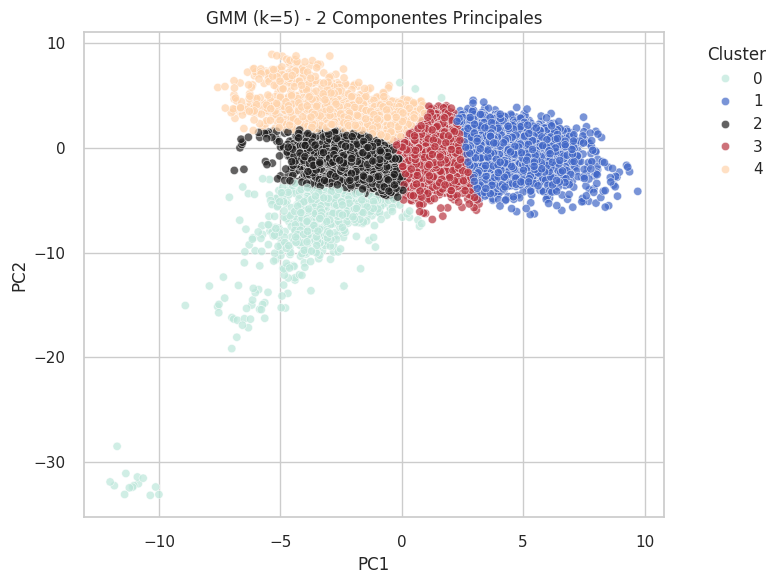

In [60]:
k_gmm = 5
modelo_gmm = GaussianMixture(n_components=k_gmm, covariance_type="full", random_state=42)

labels_gmm = modelo_gmm.fit_predict(data_pca_2D[['PC1', 'PC2']])
data_pca_2D['cluster_gmm'] = labels_gmm 

plt.figure(figsize=(8, 6))
sns.scatterplot(data=data_pca_2D, x='PC1', y='PC2', hue='cluster_gmm', palette='icefire', alpha=0.7)
plt.title(f'GMM (k={k_gmm}) - 2 Componentes Principales')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Clúster Jerárquico

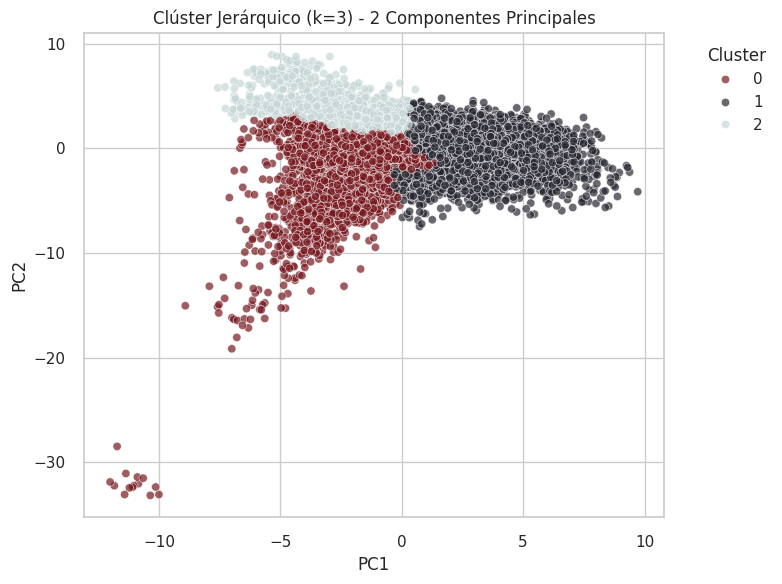

In [61]:
k_hc = 3 
modelo_hc = AgglomerativeClustering(n_clusters=k_hc, metric='euclidean', linkage='ward')

labels_hc = modelo_hc.fit_predict(data_pca_2D[['PC1', 'PC2']])
data_pca_2D['cluster_hc'] = labels_hc 

plt.figure(figsize=(8, 6))
sns.scatterplot(data=data_pca_2D, x='PC1', y='PC2', hue='cluster_hc', palette=custom_palette_aux, alpha=0.7)
plt.title(f'Clúster Jerárquico (k={k_hc}) - 2 Componentes Principales')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### DBSCAN

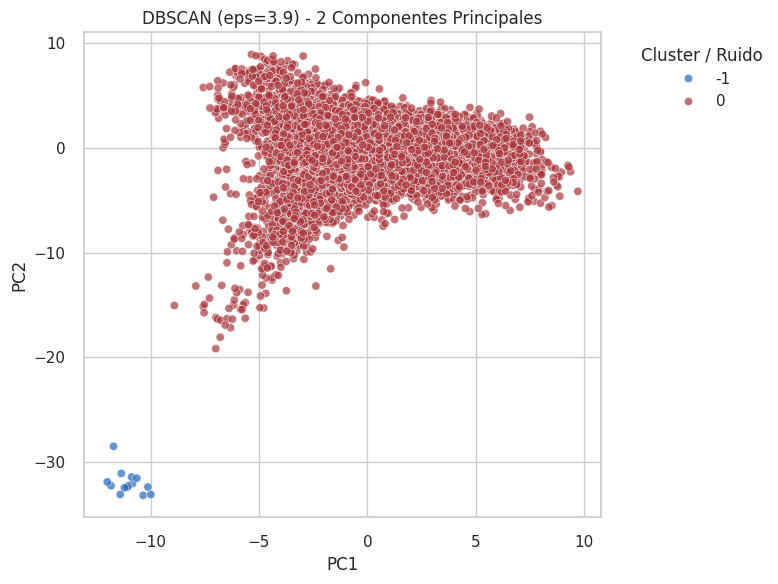

In [62]:
eps_optimo = 3.9         
min_samples_optimo = 15
modelo_dbscan = DBSCAN(eps=eps_optimo, min_samples=min_samples_optimo)

labels_dbscan = modelo_dbscan.fit_predict(data_pca_2D[['PC1', 'PC2']])
data_pca_2D['cluster_dbscan'] = labels_dbscan 

etiquetas_unicas = sorted(data_pca_2D['cluster_dbscan'].unique())
colores_dbscan = {
    label: '#808080' if label == -1 else sns.color_palette(custom_palette)[i % 9] 
    for i, label in enumerate(etiquetas_unicas)
}

plt.figure(figsize=(8, 6))
sns.scatterplot(data=data_pca_2D, x='PC1', y='PC2', hue='cluster_dbscan', palette='vlag', alpha=0.7)
plt.title(f'DBSCAN (eps={eps_optimo}) - 2 Componentes Principales')
plt.legend(title='Cluster / Ruido', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 📄 4. Resumen del Modelado

Posterior a la limpieza y exploración de los datos, se realizaron 4 modelos de aprendizaje no supervisado para determinar el número de clústers adecuados. Se exploraron:
* KMEANs
* GMM
* Clúster Jerárquico
* DBSCAN

Cada método se aplicó a dos conjunto de datos, el primero con el total de las columnas y el segundo luego de realizar una reducción de dimensiones mediante PCA.

* KMEAN: se determinó el número adecuado de grupos a través del **gráfico del codo** y también del valor del **silhouette score**.
* GMM: el número óptimo de clústers se obtuvo a través de la gráfica del codo empleando AIC y BIC; y de igual forma el valor del **silhouette score**.
* Clúster Jerárquico: se calculó el número óptimo de clusters mediante dendogramas y el **score de la silueta**.
* DBSCAN: se determinó el número adecuado de grupos a través del gráfico de la distancia *k* y el radio épsilon.


Los resultados obtenidos fueron los siguientes:

**1.- KMEANs:**
* Con todas las variables:
    * Gráfico del codo: recomienda 8 grupos
    * Score de Silueta: recomienda 6 grupos con un score de 0.116
* Con PCA:
    * Gráfico del codo: recomienda 6 grupos
    * Score de Silueta: recomienda 5 grupos con un score de 0.117

**2.- GMM:**
* Con todas las variables:
    * Gráfico del codo AIC/BIC: recomienda 5 grupos.
    * Score de Silueta: recomienda 2 grupos con un score de 0.111
* Con PCA:
    * Gráfico del codo AIC/BIC: No tiene punto de inflexión representativo.
    * Score de Silueta: recomienda 2 grupos con un score de 0.08

**3.- Clúster Jerárquico:**
* Con todas las variables:
    * Dendograma: recomienda 6 grupos.
    * Score de Silueta: recomienda 3 grupos con un score de 0.118
* Con PCA:
    * Dendograma: recomienda 6 grupos
    * Score de Silueta: recomienda 6 grupos con un score de 0.08

**4.- DBSCAN:**
* Con PCA (Varianza Explicada 95%):
    * Curva K-Distance: recomienda 6 grupos.
* Con PCA (Varianza Explicada 80%):
    * Curva K-Distance: recomienda 4 grupos.

## 📄 5. Perfilamiento

Tras evaluar 4 algoritmos (K-Means, GMM, Jerárquico y DBSCAN) en espacios de dimensionalidad original y reducida (PCA), se seleccionó el modelo de Clustering Jerárquico sobre los componentes principales con k=3. Si bien, gran parte de los modelos mostraron una clasificación óptima de 6 grupos, el clúster jerarquico mostró el score de silueta más alto con 3 divisiones. Esto permite una mejor distribución de los datos al graficarlos en baja dimensionalidad y permite desarrollar estrategias comerciales más accionables al mercado de Airbnb en la CDMX.

In [63]:
resumen(data_pca_optimo,5)

Total de filas: 23833 
Total de columnas: 32 
Total de elementos: 762656


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32
0,-2.28,-0.42,2.72,1.47,-0.41,-0.15,0.22,1.69,4.11,-1.69,-2.57,0.30,0.79,1.00,0.99,0.12,-0.43,-0.10,0.41,0.14,-0.34,-1.11,0.19,0.65,0.13,0.37,0.80,-0.84,0.41,-0.07,-0.10,-0.44
1,-3.04,3.29,-1.15,-0.39,5.55,0.30,-1.23,2.26,2.26,-0.09,2.04,0.48,0.85,-1.74,-0.16,-1.68,0.31,0.82,0.29,1.25,0.01,-1.17,1.24,0.44,-0.04,0.34,-0.83,0.78,-0.23,0.05,-0.36,-0.55
2,-1.58,2.95,-1.05,0.62,-1.60,-1.35,0.10,4.43,0.85,0.52,1.07,0.07,0.38,-0.97,0.16,-1.70,0.42,0.25,0.62,0.93,0.81,-0.71,0.77,0.16,-1.15,-0.52,-0.97,0.83,-0.68,-0.09,-0.21,0.18
3,-0.76,2.20,0.34,-1.05,0.23,0.14,-1.41,3.71,3.09,0.21,1.37,-1.02,1.78,-0.57,1.22,-0.98,-1.43,0.89,-0.26,0.52,0.44,-0.60,1.21,0.22,-0.32,-0.39,-0.69,1.02,-0.60,-0.03,0.16,-0.00
4,-1.15,2.74,-1.91,-0.24,-2.55,-0.15,0.04,-0.36,-0.08,0.12,0.48,-1.16,-1.52,0.03,0.37,-1.21,-0.49,-1.60,2.03,-0.44,-0.99,-0.19,-0.67,-0.18,0.39,0.23,-0.61,-0.48,0.53,0.07,-0.14,0.37


In [64]:
best_k = 3
# modelo_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
# etiquetas_optimas = modelo_final.fit_predict(data_pca_optimo)
modelo_final_hc = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
etiquetas_optimas = modelo_final_hc.fit_predict(df_scaled)
# modelo_final_gmm = GaussianMixture(n_components=best_k, covariance_type="full", random_state=42)
# etiquetas_optimas = modelo_final_gmm.fit_predict(df_scaled)

sil = silhouette_score(df_scaled, etiquetas_optimas)
print(f"Modelo final: Clúster Jerárquico + Todas las variables (k={best_k})")
print(f"Silhouette score: {sil:.4f}")
print(f"\nDistribución de listings por cluster:")
print(pd.Series(etiquetas_optimas).value_counts().sort_index())

Modelo final: Clúster Jerárquico + Todas las variables (k=3)
Silhouette score: 0.1182

Distribución de listings por cluster:
0    18308
1     4915
2      610
Name: count, dtype: int64


In [65]:
# Dataset original
df_resumen_sin_outliers = df_resumen_sin_outliers.reset_index(drop=True)
df_resumen_sin_outliers['cluster'] = etiquetas_optimas
resumen(df_resumen_sin_outliers,5)

Total de filas: 23833 
Total de columnas: 55 
Total de elementos: 1310815


,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_days_experience,days_since_first_review,days_since_last_review,n_amenities,n_host_verifications,fg_review,cluster
0,WITHIN AN HOUR,100.00,100.00,0.00,1,1,1.00,19.38,-99.27,OTROS,ENTIRE HOME/APT,2,1,1,1,3673,1,7,1,1,7,7,1.00,7.00,28,58,88,363,0,0,0,94,0,0,0,4.84,4.88,4.85,4.92,4.92,4.92,4.80,0,1,1,0,0,0.00,5571,908.00,28.00,12,3,0,0
1,WITHIN A DAY,100.00,100.00,1.00,1,5,1.00,19.44,-99.16,ENTIRE CONDO,ENTIRE HOME/APT,2,1,1,1,591,15,250,15,15,250,250,15.00,250.00,0,28,58,333,84,1,0,63,0,30,17730,4.87,4.95,4.88,4.98,4.94,4.76,4.79,0,1,1,0,0,0.48,5458,"5,293.00",213.00,28,2,1,2
2,WITHIN A FEW HOURS,88.00,43.00,0.00,3,4,1.00,19.41,-99.17,ENTIRE RENTAL UNIT,ENTIRE HOME/APT,4,2,2,3,1090,2,30,2,2,30,30,2.00,30.00,0,9,9,252,50,1,0,9,4,6,137397,4.90,4.82,4.76,4.94,4.92,4.98,4.92,0,2,2,0,0,0.30,5381,"5,064.00",333.00,21,2,1,0
3,WITHIN A FEW HOURS,100.00,89.00,1.00,3,4,1.00,19.35,-99.16,ENTIRE RENTAL UNIT,ENTIRE HOME/APT,2,1,1,1,1064,3,180,3,4,180,180,3.40,180.00,4,19,49,234,134,8,0,51,9,48,116373,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0,3,2,1,0,0.81,5514,"4,975.00",41.00,50,3,1,0
4,WITHIN AN HOUR,100.00,100.00,0.00,3,4,1.00,19.35,-99.16,OTROS,PRIVATE ROOM,2,2,2,3,1121,1,730,1,1,730,730,1.00,730.00,0,0,0,0,0,0,0,0,0,0,137586,4.84,4.88,4.85,4.92,4.92,4.92,4.80,0,3,1,2,0,0.00,5234,908.00,28.00,10,1,0,0


In [66]:
vars_continuas = [
    "price", "accommodates", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "availability_365",
    "review_scores_rating", "review_scores_value",
    "reviews_per_month", "number_of_reviews",
    "host_listings_count", "n_amenities"
]
vars_binarias = ["host_is_superhost", "instant_bookable"]

means_cont = df_resumen_sin_outliers.groupby("cluster")[vars_continuas].mean().round(2)
means_bin = (df_resumen_sin_outliers.groupby("cluster")[vars_binarias].mean() * 100).round(1)
means_bin = means_bin.rename(columns={
    "host_is_superhost": "%_is_superhost",
    "instant_bookable": "%_instant_bookable"
})
conteos = df_resumen_sin_outliers.groupby("cluster")['cluster'].count()
tabla_abs = means_cont.join(means_bin).join(conteos)

print("Valores absolutos por cluster")
display(tabla_abs.T)

Valores absolutos por cluster


cluster,0,1,2
price,"1,245.39","1,597.21","1,347.49"
accommodates,2.92,4.11,2.48
bedrooms,1.40,1.72,1.47
beds,1.72,2.26,1.60
minimum_nights,2.04,1.60,22.83
maximum_nights,456.63,532.92,449.90
availability_365,226.01,250.80,179.30
review_scores_rating,4.78,4.82,4.82
review_scores_value,4.75,4.79,4.76
reviews_per_month,1.12,2.95,0.26


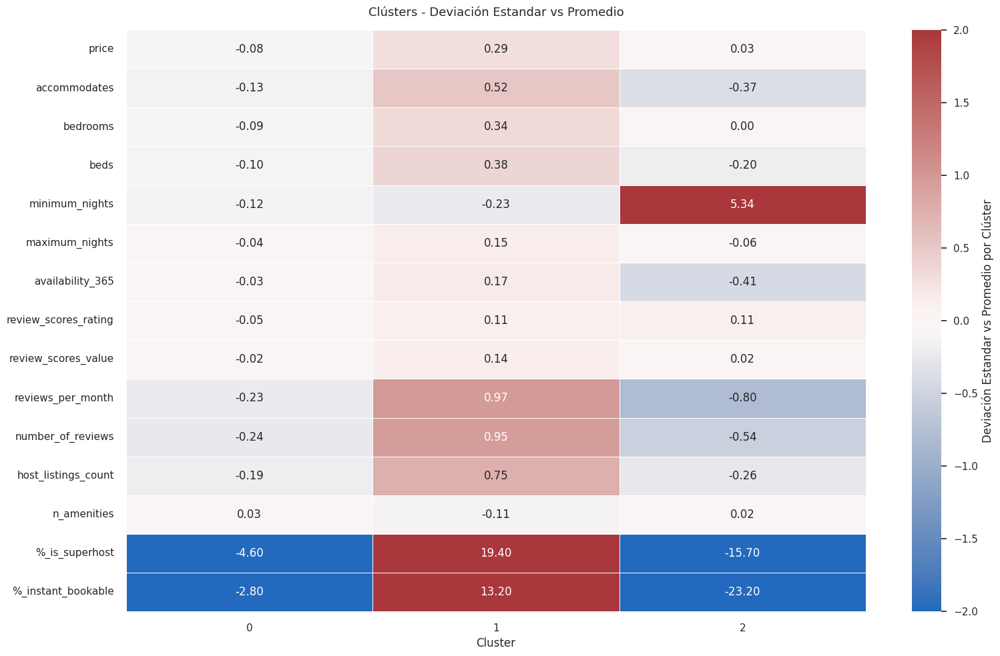

In [67]:
global_mean = df_resumen_sin_outliers[vars_continuas].mean()
global_std  = df_resumen_sin_outliers[vars_continuas].std()
z_cont = ((means_cont - global_mean) / global_std).round(2)

global_bin = (df_resumen_sin_outliers[vars_binarias].mean() * 100)
z_bin = (means_bin - global_bin.rename({
    "host_is_superhost": "%_is_superhost",
    "instant_bookable": "%_instant_bookable"
})).round(1)
tabla_z = z_cont.join(z_bin)


fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    tabla_z.T,
    annot=True,
    fmt=".2f",
    cmap='vlag',
    center=0,
    vmin=-2, vmax=2,
    cbar_kws={'label': 'Deviación Estandar vs Promedio por Clúster'},
    linewidths=0.5,
    ax=ax
)
ax.set_title("Clústers - Deviación Estandar vs Promedio", fontsize=13, pad=15)
ax.set_xlabel("Cluster")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

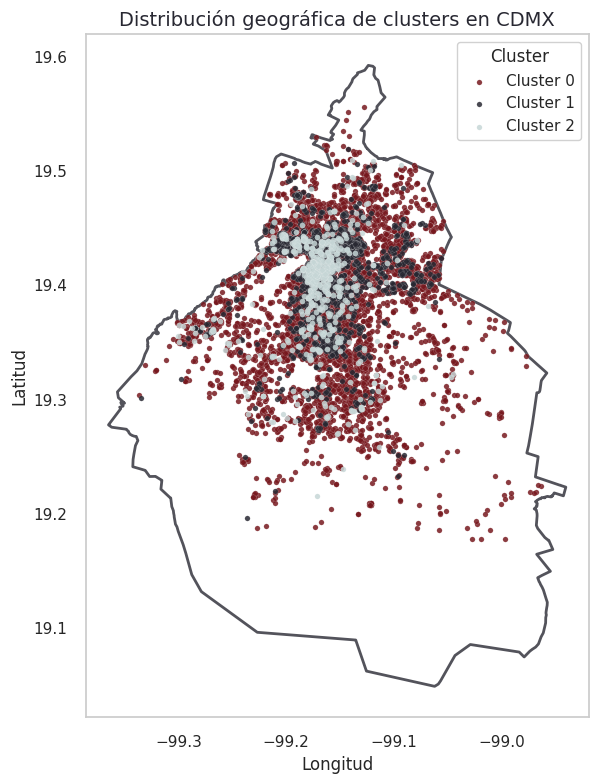

In [68]:
fig, ax = plt.subplots(figsize=(10, 8))



df_mapa = df_resumen_sin_outliers

for cluster_id in sorted(df_mapa['cluster'].unique()):
    subset = df_mapa[df_mapa['cluster'] == cluster_id]
    ax.scatter(
        x=subset['longitude'],
        y=subset['latitude'],
        c=custom_palette_aux[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.85,
        edgecolors='w',
        linewidth=0.1,
        s=15,
        zorder=5
    )

ax.set_title('Distribución geográfica de clusters en CDMX', fontsize=14, color=color1)
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
ax.grid(False)

# Contorno CDMX
cdmx_boundary = ox.geocode_to_gdf("Ciudad de México, México")
cdmx_boundary.plot(ax=ax, facecolor='none', edgecolor=color1, linewidth=2, alpha=0.8)

# Leyenda
ax.legend(title='Cluster', loc='upper right', frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

In [69]:
colores_cluster = {0: '#77181e', 1: '#282832', 2: '#c6d6d6'}
nombres_cluster = {
    0: '0',
    1: '1',
    2: '2'
}

def kde_destacado(ax, columna, cluster_destacado, xlim_q=0.98, titulo='', df=df_resumen_sin_outliers):
    for c in [0, 1, 2]:
        if c == cluster_destacado:
            continue
        sns.kdeplot(df[df['cluster']==c][columna], ax=ax,
                    color=colores_cluster[c], linewidth=1.5,
                    label=nombres_cluster[c])
    sns.kdeplot(df[df['cluster']==cluster_destacado][columna], ax=ax,
                color=colores_cluster[cluster_destacado], alpha=0.35, linewidth=2.5,
                fill=True, label=nombres_cluster[cluster_destacado])
    ax.set_xlim(0, df[columna].quantile(xlim_q))
    ax.set_title(titulo, fontsize=11)
    ax.legend(fontsize=8)

### Clúster 0: Mercado Base

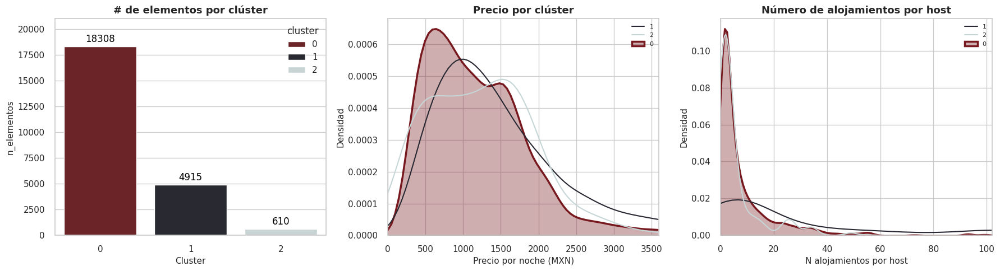

In [70]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df_resumen_sin_outliers, 
              x='cluster', 
              hue='cluster', 
              palette=custom_palette_aux, 
              order=df_resumen_sin_outliers['cluster'].value_counts().index, 
              ax=axes[0])
axes[0].set_title('# de elementos por clúster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=11)     
axes[0].set_ylabel('n_elementos', fontsize=11)
axes[0].margins(y=0.15)
for container in axes[0].containers:
    axes[0].bar_label(container, label_type='edge', padding=3, color='black', fontsize=12)

kde_destacado(axes[1], 'price', 0, xlim_q=0.97)
axes[1].set_title('Precio por clúster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Precio por noche (MXN)', fontsize=11)
axes[1].set_ylabel('Densidad', fontsize=11)

kde_destacado(axes[2], 'host_listings_count', 0, xlim_q=0.97)
axes[2].set_title('Número de alojamientos por host', fontsize=13, fontweight='bold')
axes[2].set_xlabel('N alojamientos por host', fontsize=11)
axes[2].set_ylabel('Densidad', fontsize=11)

plt.tight_layout()
plt.show()

El grueso del la plataforma de Airbnb en CDMX. Anfitriones individuales o semi-profesionales con 1-2 propiedades, operando en zonas residenciales fuera del centro. Es el "promedio" del mercado en casi todo: precio medio, capacidad media, ocupación moderada.

Precio $1,245 MXN/noche, capacidad 2.92 personas
8 listings por host (operación pequeña)
1.12 reviews/mes y 33 reviews acumuladas (rotación baja-media)
Solo 33.7% son superhost, 37.9% instant_bookable
Mejor dotación de amenities que el cluster 1 (13.8 vs 11.63)

Se encuentran distribuidos por toda la CDMX, probablemente con presencia fuerte en colonias residenciales de clase media.

### Clúster 1: Alojamientos Premium

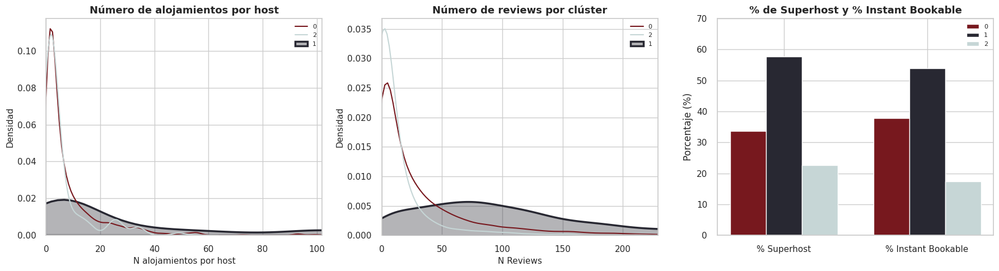

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

kde_destacado(axes[0], 'host_listings_count', 1, xlim_q=0.97)
axes[0].set_title('Número de alojamientos por host', fontsize=13, fontweight='bold')
axes[0].set_xlabel('N alojamientos por host', fontsize=11)
axes[0].set_ylabel('Densidad', fontsize=11)

kde_destacado(axes[1], 'number_of_reviews', 1, xlim_q=0.97)
axes[1].set_title('Número de reviews por clúster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('N Reviews', fontsize=11)
axes[1].set_ylabel('Densidad', fontsize=11)

metricas = ['% Superhost', '% Instant Bookable']
valores = {
    0: [33.7, 37.9],
    1: [57.7, 53.9],
    2: [22.6, 17.5]
}
x = np.arange(len(metricas))
ancho = 0.25
for i, c in enumerate([0, 1, 2]):
    axes[2].bar(x + (i-1)*ancho, valores[c], ancho,
           label=nombres_cluster[c], color=colores_cluster[c])
axes[2].set_xticks(x)
axes[2].set_title('% de Superhost y % Instant Bookable', fontsize=13, fontweight='bold')
axes[2].set_xticklabels(metricas)
axes[2].set_ylabel('Porcentaje (%)')
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, 70)



plt.tight_layout()
plt.show()

Hosts profesionales o empresas de gestión inmobiliaria que operan alojamientos medianos en zonas céntricas y turísticas. Es el segmento de mayor valor por listing y el más rentable para Airbnb como plataforma.

Precio premium: $1,597 MXN/noche, cuentan con mayor capacidad: 4.11 personas, 1.72 recámaras (departamentos completos). Su operación es más profesional dado que el cada host cuenta en promedio con 41.7 alojamientos lo que representa 5 veces más que el cluster 0. Presentan más reviews acumuladas y 2.95 reviews/mes, indicando una alta rotación. De igual forma el 57.7% es superhost y el 53.9% puede ser rentado al instante. Tienen alta (250 días/año).

Se encuentran principalmente en el centro turístico de la Ciudad de México, en la colonias: Roma, Condesa, Polanco, Centro Histórico, Juárez. Tienen los minimum_nights más bajos (1.6) confirman que están optimizados para estancias cortas de turistas, lo que se traduce en máxima rotación y máximo número de reviews.

### Clúster 2: Estancias Largas

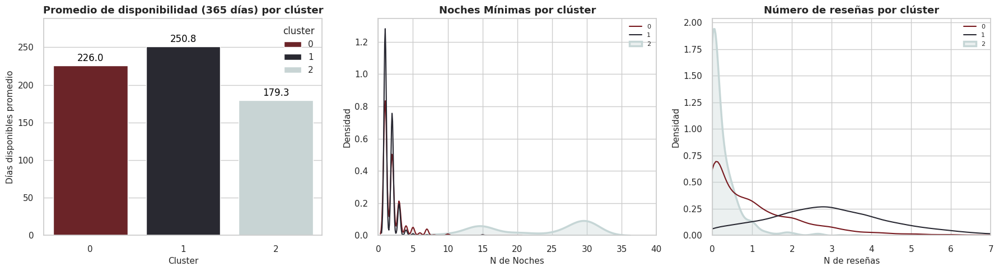

In [72]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df_aux = df_resumen_sin_outliers.groupby('cluster')['availability_365'].mean().reset_index()
sns.barplot(data=df_aux, 
            x='cluster', 
            y='availability_365', 
            hue='cluster', 
            palette=custom_palette_aux, 
            ax=axes[0])
axes[0].set_title('Promedio de disponibilidad (365 días) por clúster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=11)     
axes[0].set_ylabel('Días disponibles promedio', fontsize=11)

axes[0].margins(y=0.15)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', label_type='edge', padding=3, color='black', fontsize=12)

kde_destacado(axes[1], 'minimum_nights', 2, xlim_q=0.97)
axes[1].set_title('Noches Mínimas por clúster', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 40)
axes[1].set_xlabel('N de Noches', fontsize=11)
axes[1].set_ylabel('Densidad', fontsize=11)

kde_destacado(axes[2], 'reviews_per_month', 2, xlim_q=0.97)
axes[2].set_title('Número de reseñas por clúster', fontsize=13, fontweight='bold')
axes[2].set_xlim(0, 7)
axes[2].set_xlabel('N de reseñas', fontsize=11)
axes[2].set_ylabel('Densidad', fontsize=11)

plt.tight_layout()
plt.show()

Es un grupo de alojamientos muy diferenciado orientados a rentas mensuales o corporativas. Los rasgos más distintivos del dataset es la cantidad de Minimum nights = 22.83, cuentan con solo 0.26 reviews/mes y 12.7 acumuladas.

Tienen baja disponibilidad (179 días), lo que genera largos bloqueos por inquilinos prolongados. El Precio medio $1,347 que no es tan alto pero dado que suelen ser estancias prolongadas el costo mensual puede ser muy alto. 
Los host tienen baja cantidad de alojamientos 6 en promedio.
Solo 17.5% es instant_bookable lo que indica que la mayoría de los alojamientos están ocupados. 
Calificación alta (4.82) a pesar de baja rotación, es decir, cuando reciben huésped, lo hacen bien

Los alojameintos se encuentran dispersos por la ciudad, con presencia en zonas atractivas para personas que vienen de fuera para rentas largas, trabajadores, empresas, etc.

### Conclusión

El análisis geográfico revela que la segmentación no es solo estadística sino espacialmente coherente: el Cluster 1 se concentra en el núcleo turístico de la CDMX (Roma, Condesa, Polanco, Centro), lo que explica simultáneamente sus tres rasgos definitorios — mayor precio (premium por ubicación), menor minimum_nights (optimizado para turismo de paso) y mayor número de reviews (máxima rotación). Esto valida que el clustering capturó dinámicas reales del mercado y no solo correlaciones estadísticas.